In [119]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [120]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error, \
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss, confusion_matrix,roc_curve
from sklearn.linear_model import LinearRegression, LogisticRegression, SGDClassifier
from sklearn.model_selection import learning_curve

from IPython.display import display

%matplotlib inline

## 1. Разведочный анализ данных (EDA)

In [121]:
df = pd.read_csv('student_lifestyle_100k.csv', sep=',')
display(df.head())
df.info()
display(df.describe().round(2))

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  str    
 3   Department          100000 non-null  str    
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), str(2)
memory usage: 7.7 MB


,Student_ID,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
count,100000.00,100000.00,100000.00,100000.0,100000.00,100000.00,100000.00,100000.00
mean,51000.50,21.01,2.90,7.0,4.51,3.50,74.35,4.13
std,28867.66,2.00,0.53,1.5,1.98,1.49,43.37,1.42
min,1001.00,18.00,1.56,3.0,0.00,0.00,0.00,2.00
25%,26000.75,19.00,2.45,6.0,3.20,2.50,37.00,3.00
50%,51000.50,21.00,2.90,7.0,4.50,3.50,74.00,4.00
75%,76000.25,23.00,3.35,8.0,5.80,4.50,112.00,5.00
max,101000.00,24.00,4.00,12.0,12.80,10.00,149.00,10.00


Из таблицы ниже явных аномалий (по типу отрицательного возраста или запредельных значений) не выявлено

Удаляем Student_ID, дубликаты строк и пустые значения

In [122]:
df.drop(columns='Student_ID', inplace=True)
df = df.drop_duplicates().dropna()
df.shape

(100000, 10)

Анализ целевых переменных (CGPA, Depression)

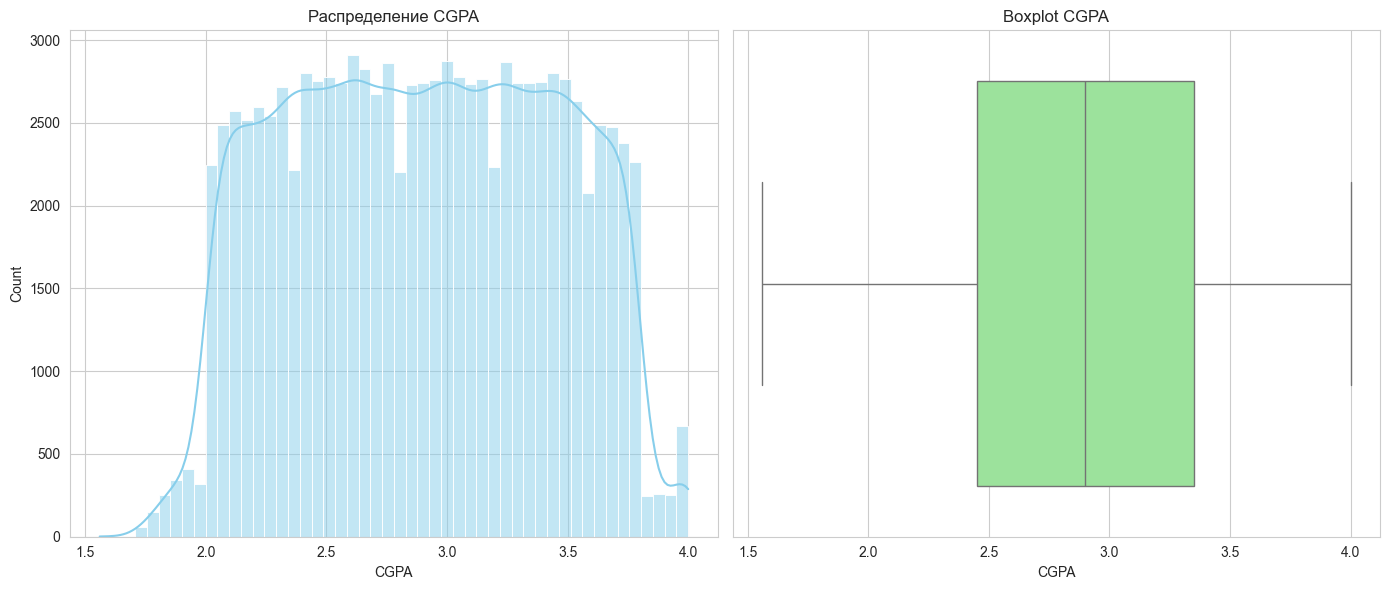

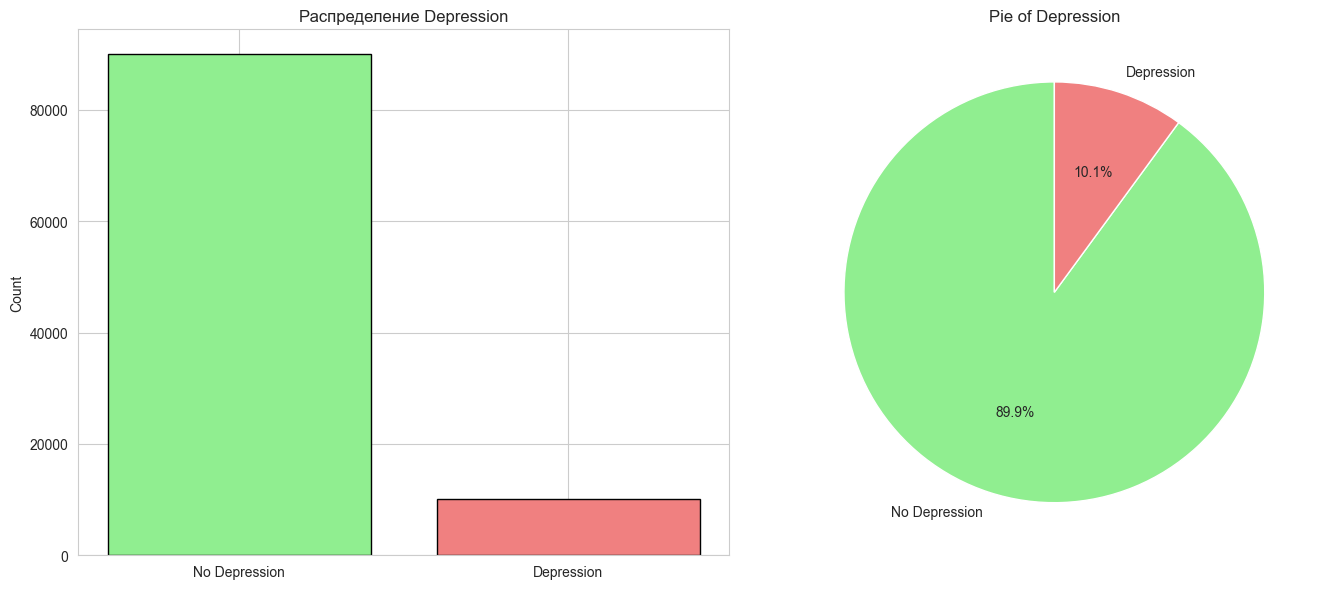

In [123]:
def analyze_target(df):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    sns.histplot(df['CGPA'], kde=True, color='skyblue', bins=50, ax=axes[0])
    axes[0].set_title('Распределение CGPA')
    axes[0].set_xlabel('CGPA')
    axes[0].set_ylabel('Count')

    sns.boxplot(x=df['CGPA'], color='lightgreen', ax=axes[1])
    axes[1].set_title('Boxplot CGPA')
    axes[1].set_xlabel('CGPA')

    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    labels = ['No Depression', 'Depression']
    depression_counts = df['Depression'].value_counts()
    values = [depression_counts.get(False), depression_counts.get(True)]
    colors = ['lightgreen', 'lightcoral']
    bars = axes[0].bar(labels, values, color=colors, edgecolor='black')
    axes[0].set_title('Распределение Depression')
    axes[0].set_ylabel('Count')

    axes[1].pie(values, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
    axes[1].set_title('Pie of Depression')

    plt.tight_layout()
    plt.show()


analyze_target(df)

Соотношение депрессии 1:9, что критично для логистической регрессии

Анализ числовых признаков

Найдено числовых признаков: 6
Признаки: ['Age', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Physical_Activity', 'Stress_Level']



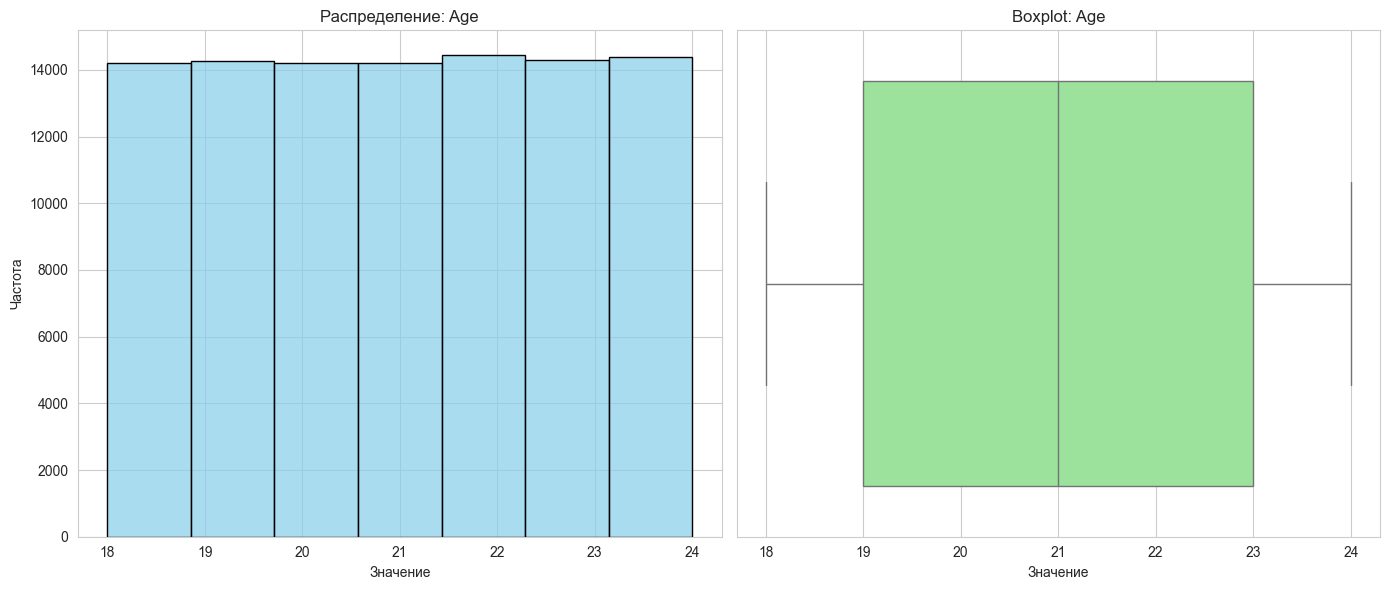

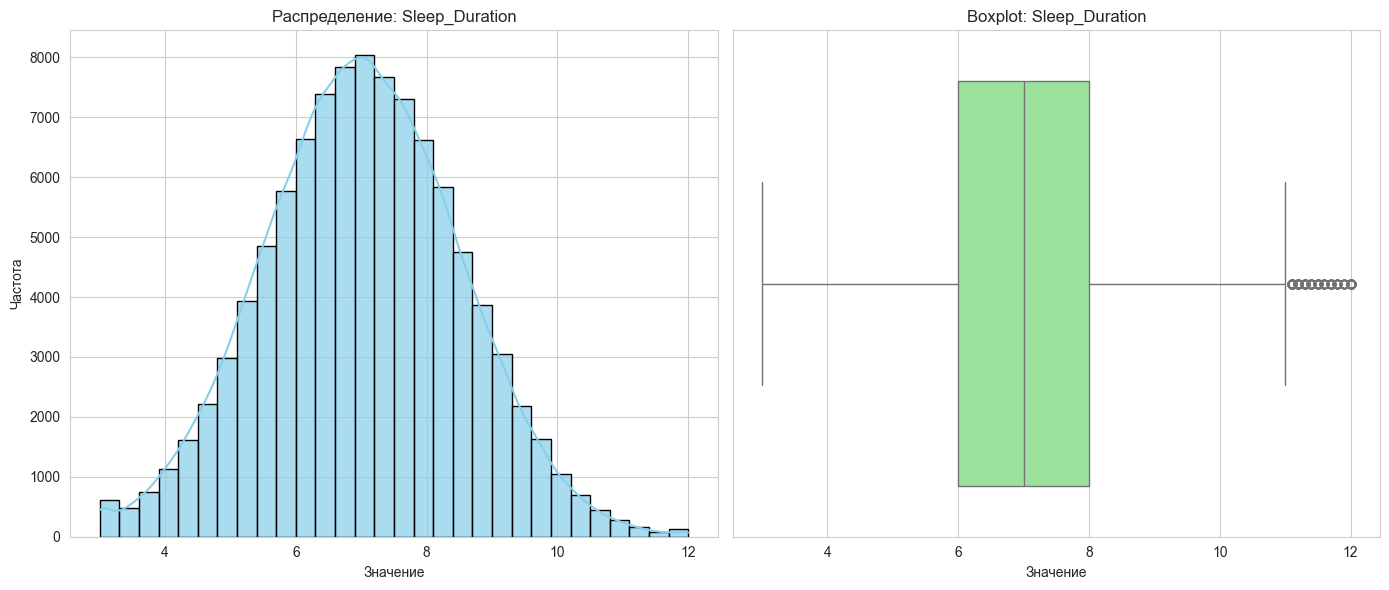

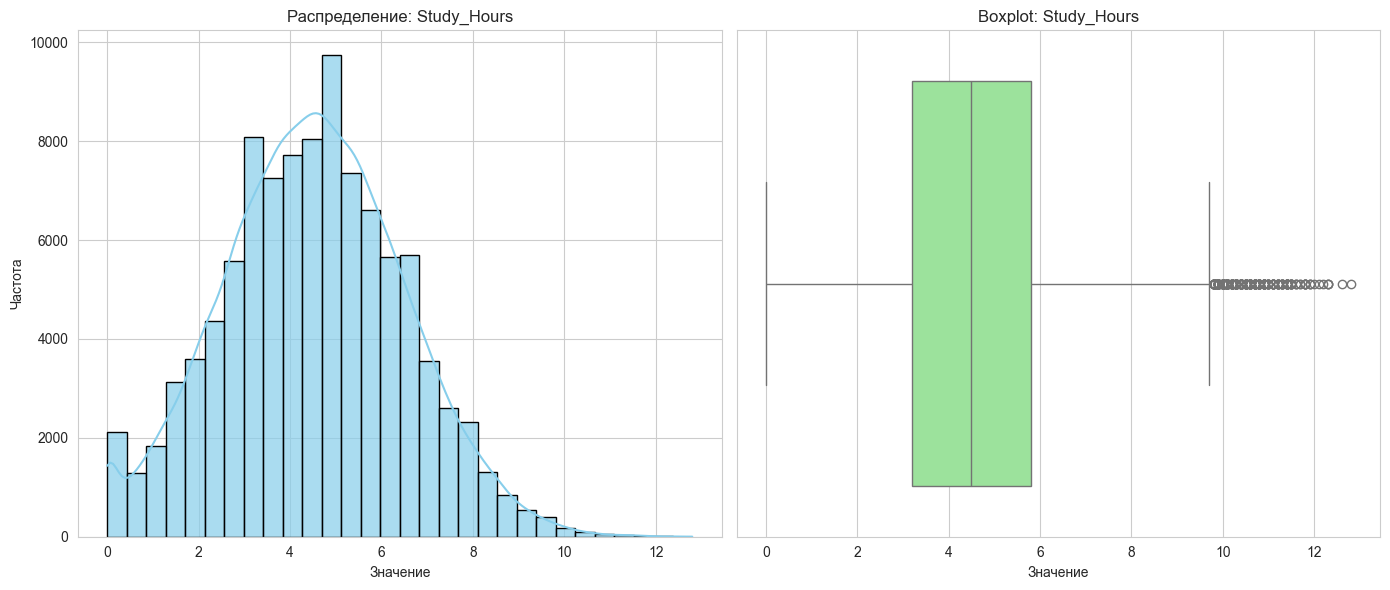

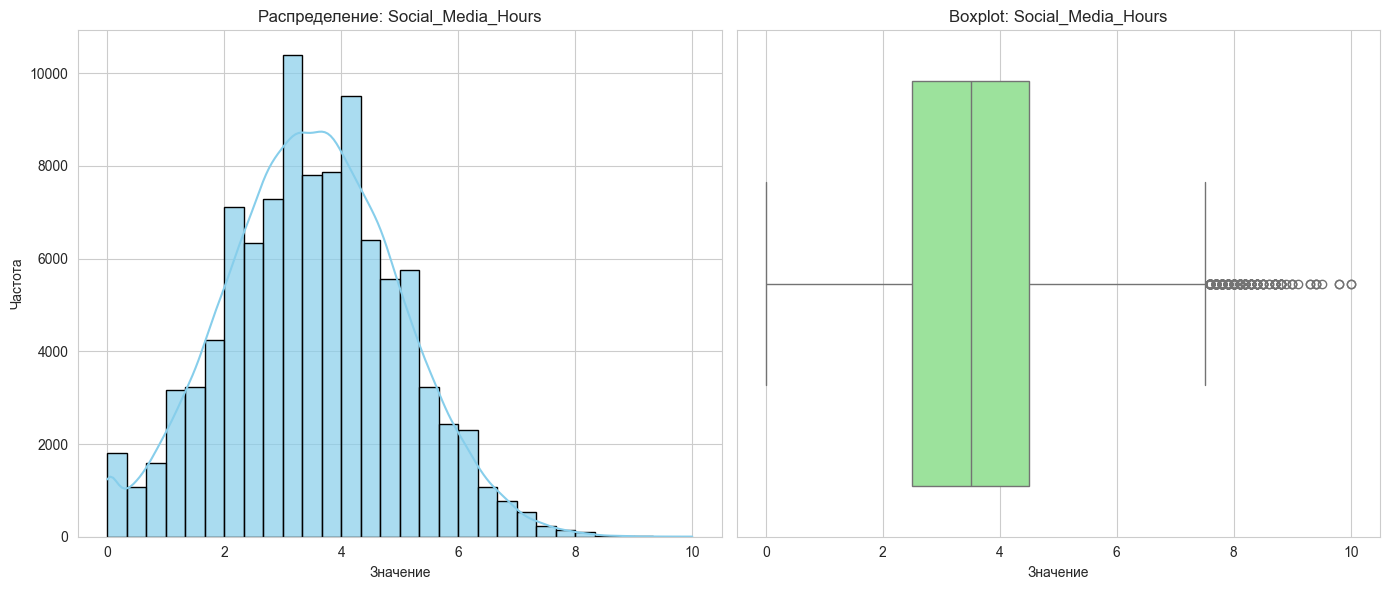

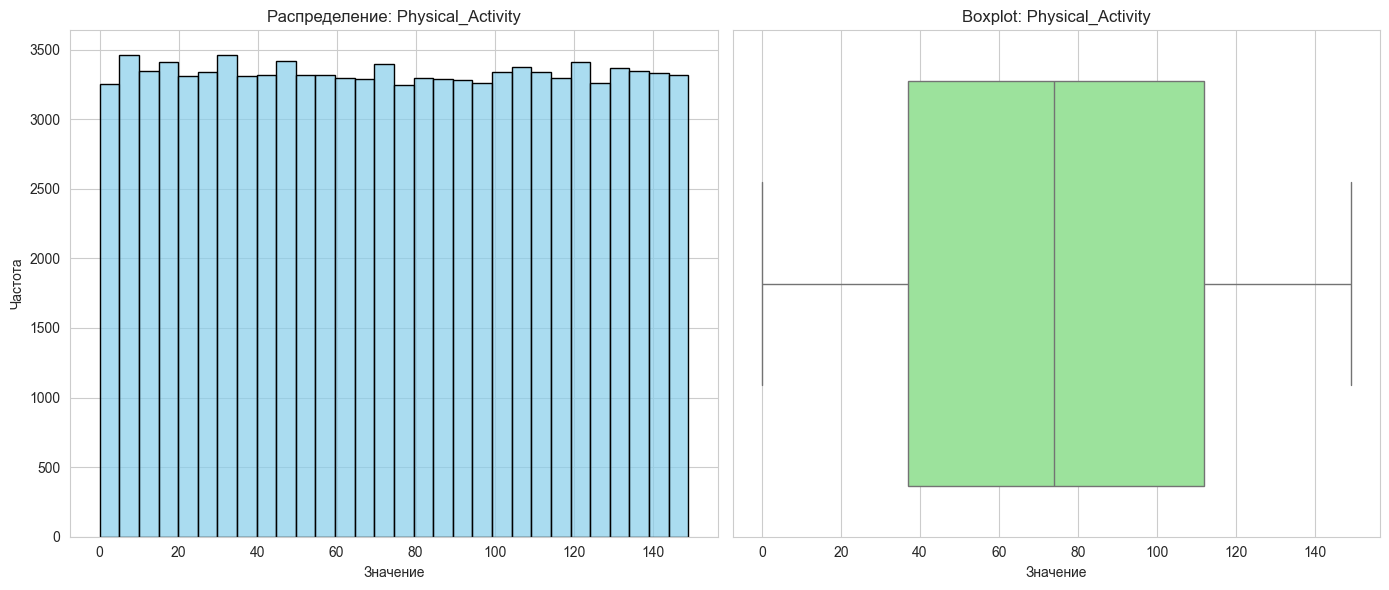

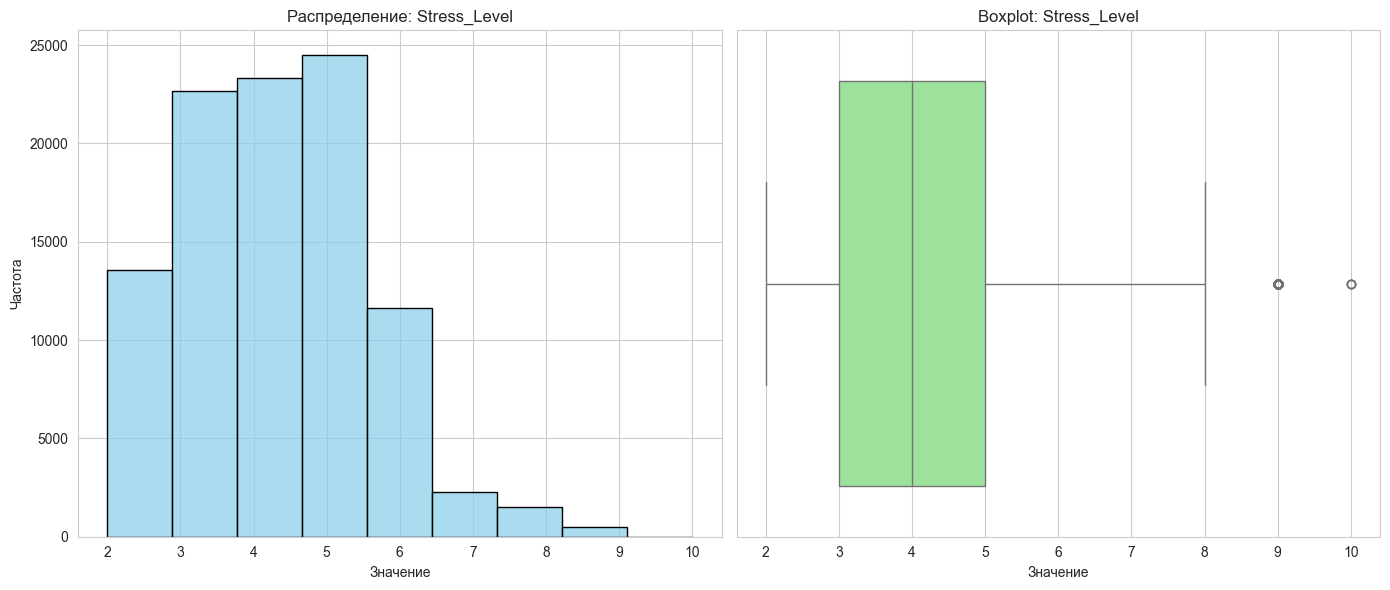

In [124]:
def analyze_number(df):
    sns.set_style('whitegrid')
    sns.set_palette('husl')

    numeric_cols = df.select_dtypes(include='number').columns.tolist()

    target_cols = ['Depression', 'CGPA']
    for col in target_cols:
        if col in numeric_cols:
            numeric_cols.remove(col)

    print(f"Найдено числовых признаков: {len(numeric_cols)}")
    print(f"Признаки: {numeric_cols}\n")

    for col in numeric_cols:
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        if df[col].dtype == int:
            bins = min(30, df[col].nunique())
            kde = False
        else:
            kde = True
            bins = 30

        sns.histplot(data=df, x=col, bins=bins, kde=kde, ax=axes[0], color='skyblue', edgecolor='black', alpha=0.7)
                
        axes[0].set_title(f'Распределение: {col}')
        axes[0].set_xlabel('Значение')
        axes[0].set_ylabel('Частота')

        sns.boxplot(data=df, x=col, ax=axes[1], color='lightgreen')
        axes[1].set_title(f'Boxplot: {col}')
        axes[1].set_xlabel('Значение')

        plt.tight_layout()
        plt.show()


analyze_number(df)

- **Age**: Равномерное распределение
- **Sleep_Duration**: Равномерное распределение, есть выбросы справа
- **Study_Hours**: Похоже на равномерное распределение, есть выбросы справа
- **Social_Media_Hours**: Похоже на равномерное распределение, есть выбросы справа
- **Physical_Activity**: Равномерное распределение
- **Stress_Level**: Распределение право-ассиметричное с выббросами в значениях 9 и 10

Анализ категориальных признаков

Найдено категориальных признаков: 4
Признаки: ['Gender', 'Department', 'Age', 'Stress_Level']



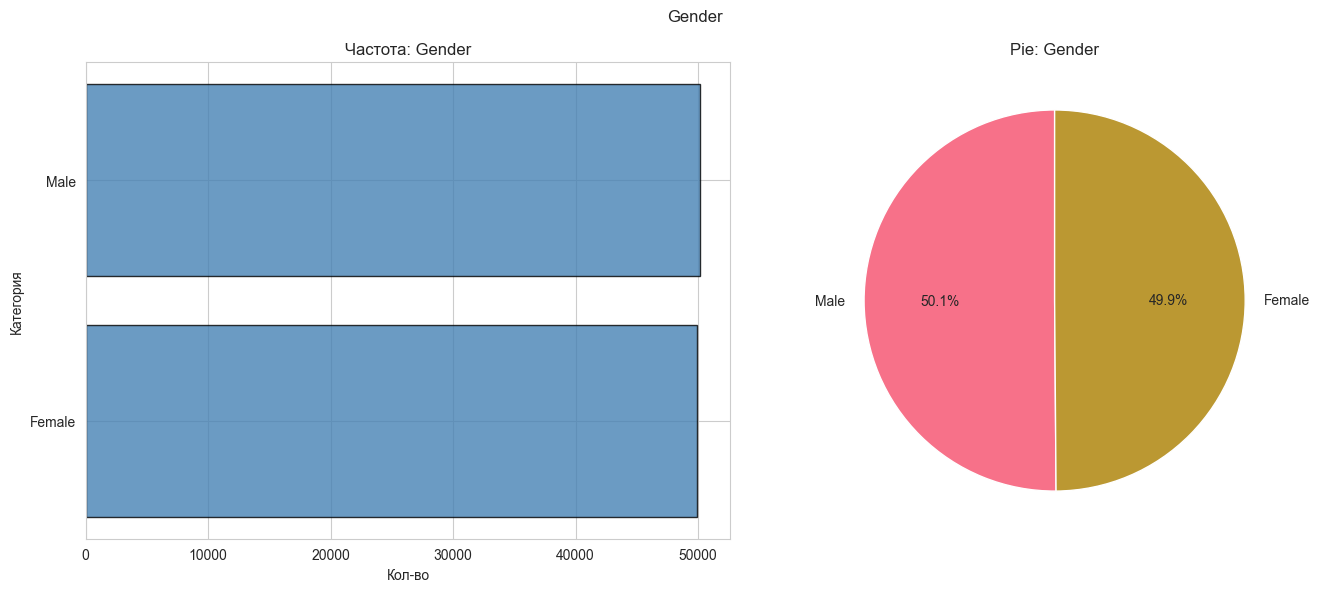

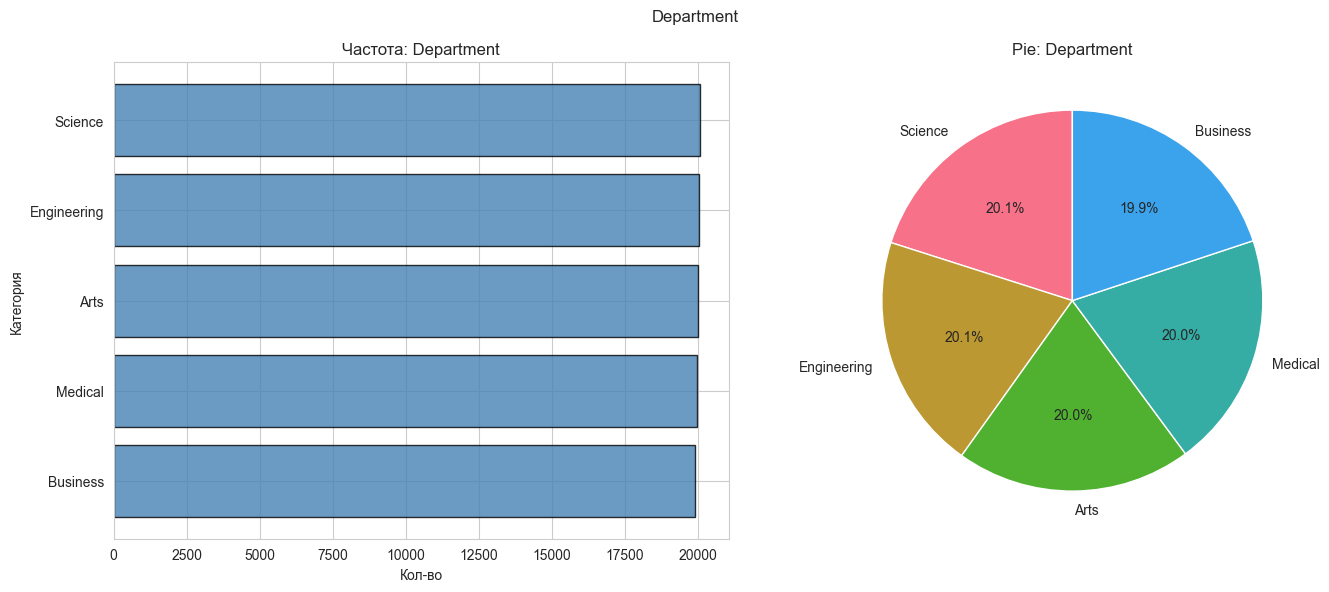

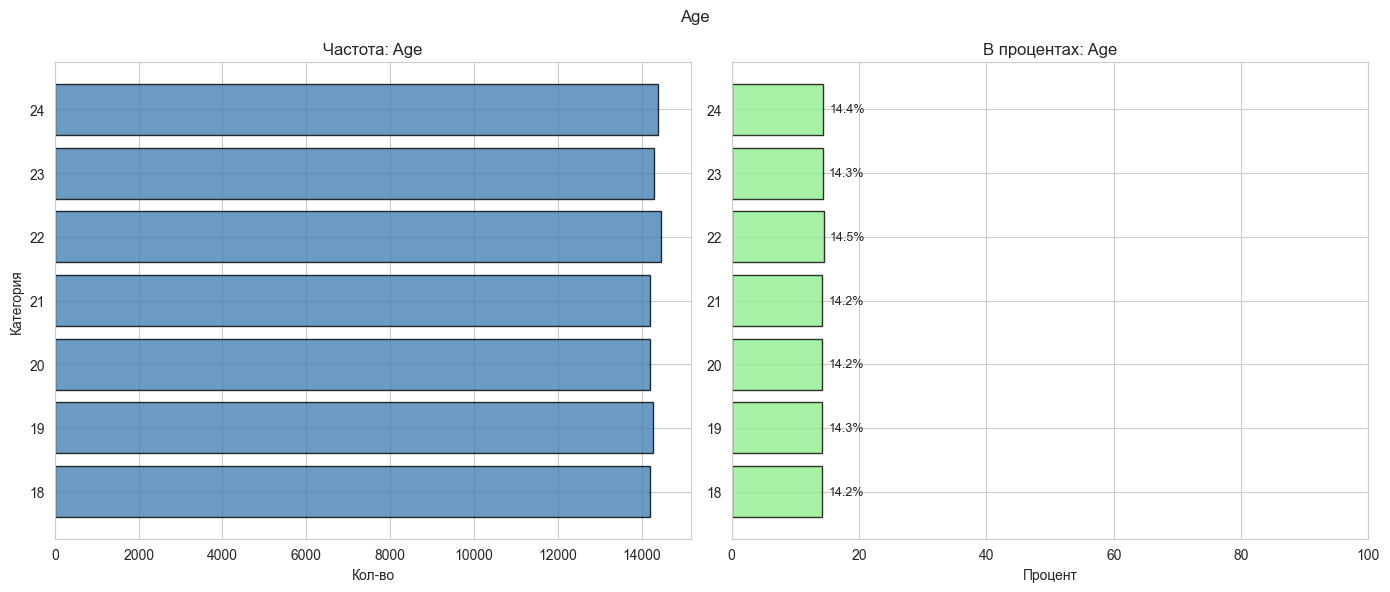

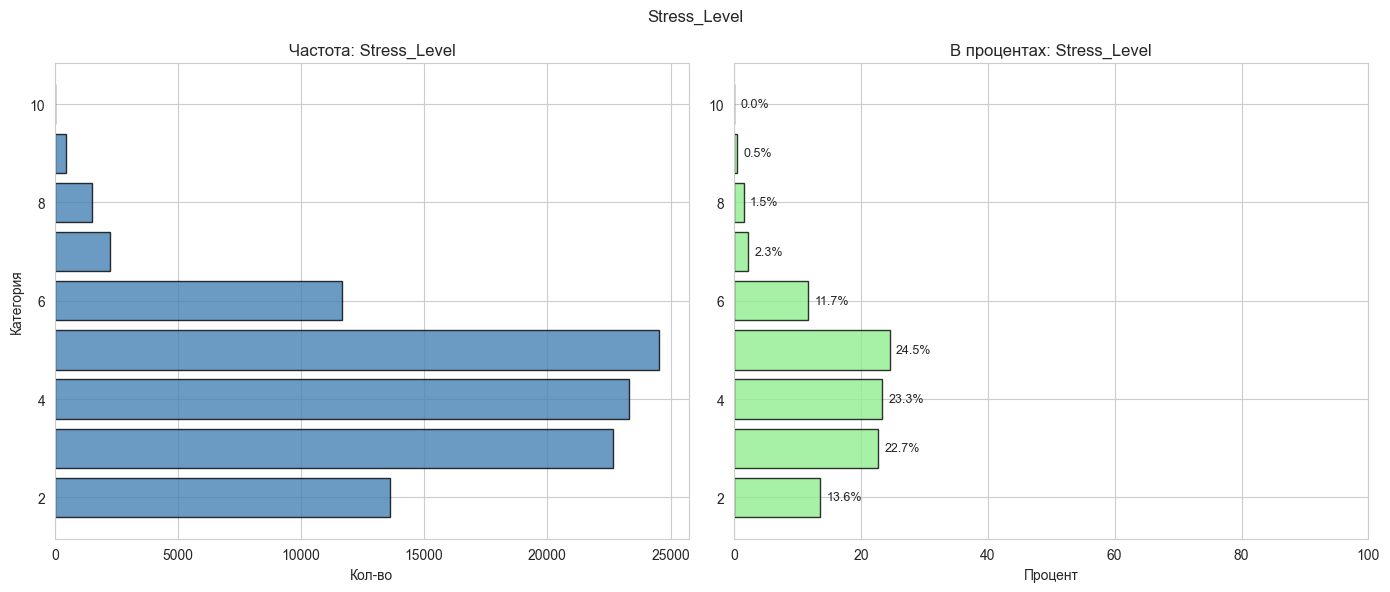

In [125]:
def analyze_categorical(df):
    cat_cols = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
    num_cols = df.select_dtypes(include='number').columns
    numeric_with_few_unique = num_cols[df[num_cols].nunique().between(2, 10)].tolist()
    cat_cols.extend(numeric_with_few_unique)

    target_cols = ['Depression', 'CGPA']
    for col in target_cols:
        if col in cat_cols:
            cat_cols.remove(col)

    print(f"Найдено категориальных признаков: {len(cat_cols)}")
    print(f"Признаки: {cat_cols}\n")

    for col in cat_cols:
        series = df[col]
        value_counts = series.value_counts()
        unique_count = value_counts.count()

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        bars = axes[0].barh(value_counts.index[::-1], value_counts.values[::-1], color='steelblue', edgecolor='black', alpha=0.8)
        axes[0].set_title(f'Частота: {col}')
        axes[0].set_xlabel('Кол-во')
        axes[0].set_ylabel('Категория')

        # pie для категорий < 7
        if unique_count < 7:
            axes[1].pie(
                value_counts.values,
                labels=value_counts.index,
                autopct='%1.1f%%',
                startangle=90,
            )
            axes[1].set_title(f'Pie: {col}')

        # или bar plot для категорий >= 7
        else:
            percentages = value_counts / value_counts.sum() * 100
            bars = axes[1].barh(percentages.index[::-1], percentages.values[::-1],
                            color='lightgreen', edgecolor='black', alpha=0.8)
            axes[1].set_title(f'В процентах: {col}')
            axes[1].set_xlabel('Процент')
            axes[1].set_xlim(0, 100)

            for bar in bars:
                width = bar.get_width()
                axes[1].text(width + 1, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', va='center', fontsize=9)

        plt.suptitle(col)
        plt.tight_layout()
        plt.show()


analyze_categorical(df)

Корреляционная матрица

In [126]:
def run_corr(df):
    df_corr = df.copy()
    df_corr['Gender_encoded'] = df_corr['Gender'].map({'Male': 0, 'Female': 1})
    df_corr['Depression_encoded'] = df_corr['Depression'].astype(int)
    df_corr['Department_encoded'] = df_corr['Department'].astype('category').cat.codes

    corr_matrix = df_corr.select_dtypes(include=['number'], exclude=['object', 'bool']).corr()

    plt.figure(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
                square=True, linewidths=1, cbar_kws={'shrink': 0.8}, mask=mask, vmin=-1, vmax=1)
    plt.title('Корреляционная матрица')
    plt.tight_layout()
    plt.show()

## 2. Feature Engineering и предобработка данных

Переведем минуты физ активности в часы, создадим новую колонку чиллового челика, найдем и удалим аномалии

(477, 11)
(99523, 11)


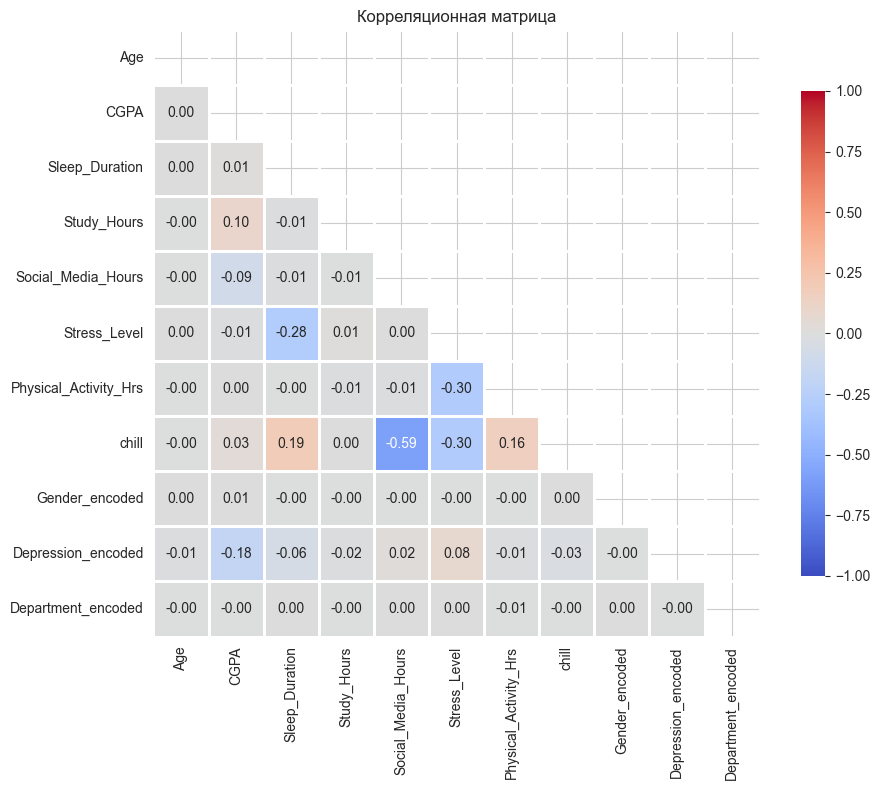

In [127]:
df['Physical_Activity_Hrs'] = round(df['Physical_Activity'] / 60, 2)

bad = df['Social_Media_Hours'] * df['Stress_Level']
r = np.where(bad >= 1, 0.01, 1)
df['chill'] = (df['Physical_Activity_Hrs'] + df['Sleep_Duration']) / (bad + r)
df.drop('Physical_Activity', axis=1, inplace=True)

# у кого больше 24 часов в сутки - аномалия
all_time = df['Physical_Activity_Hrs'] + df['Sleep_Duration'] + df['Study_Hours'] + df['Social_Media_Hours']
print(df[all_time > 24].shape)
df = df[all_time <= 24]
print(df.shape)

run_corr(df)

Из всего выделяется только -0.59. но и то потому, что эта колонка состоит из четырех других. Сильной корреляции нет, хотя можно заметить небольшую зависимость CGPA и депрессии, а также уровень стресса, который растет если человек недостаточно чиловый и много двигается


Разделение данных 50/30/20 и удаление выбросов из обучающей выборки, ведь даже небольшой их процент может сильно понизить качество обучения линейной регрессии.

In [128]:
df_train, df_temp = train_test_split(
    df, test_size=0.5, random_state=42, stratify=df["Depression"]
)

df_val, df_test = train_test_split(
    df_temp, test_size=0.4, random_state=42, stratify=df_temp["Depression"]
)

df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print(f"До удаление выбросов: {df_train.shape}")

num_cols = df_train.select_dtypes(include='number').columns.tolist()
for col in num_cols:
    Q1 = df_train[col].quantile(0.25)
    Q3 = df_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_train = df_train[(df_train[col] >= lower_bound) & (df_train[col] <= upper_bound)]

df_train = df_train.reset_index(drop=True)
print(f"После удаления выбросов: {df_train.shape}")


До удаление выбросов: (49761, 11)
После удаления выбросов: (45138, 11)


Балансировка train выборки для логистической регрессии (чтобы соотношение депрессии и недепрессии было 1:1).
Делаем ресемплинг. ТОЛЬКО для обучающей выборки, чтобы наш классификатор смотрел на реальные данные, где соотношение по прежнему 1:9

До балансировки: (45138, 11), 10.05%
(45138, 11)
После балансировки: 50.00%
(81200, 11)


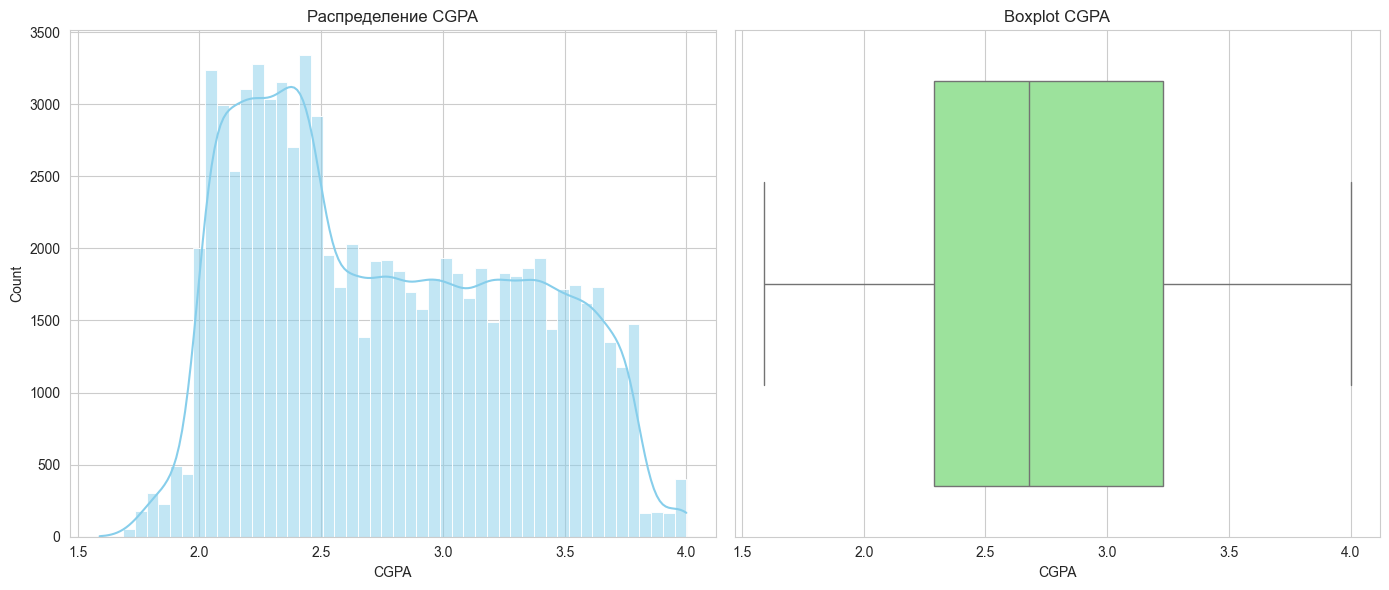

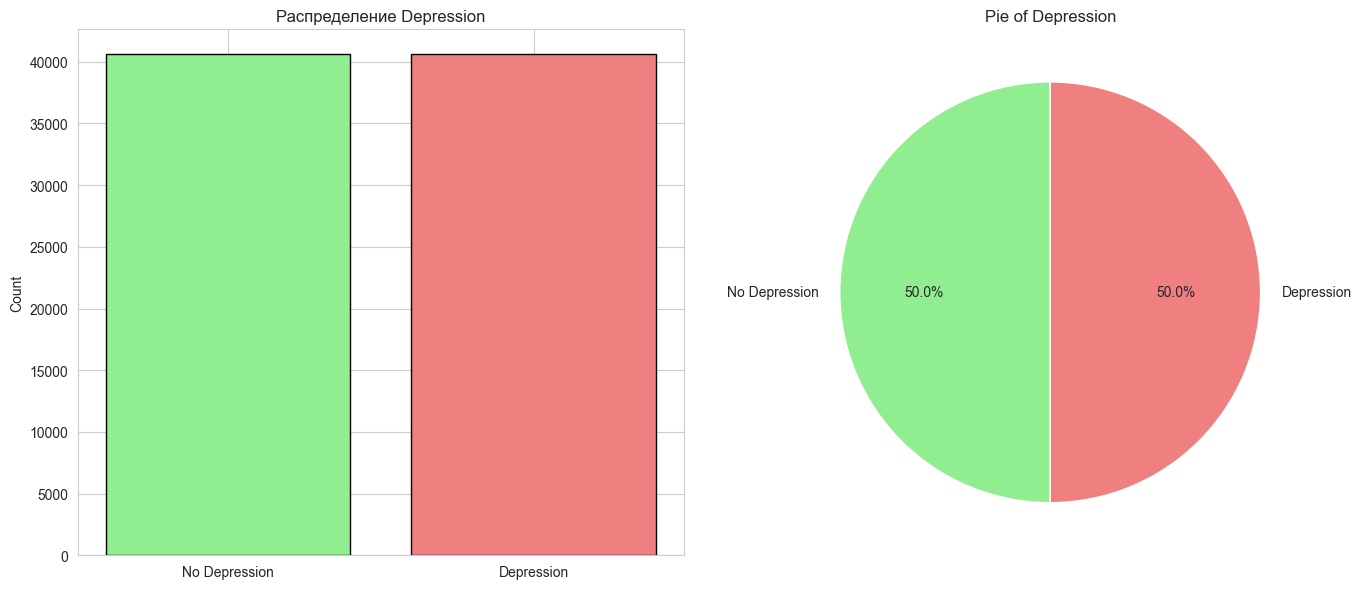

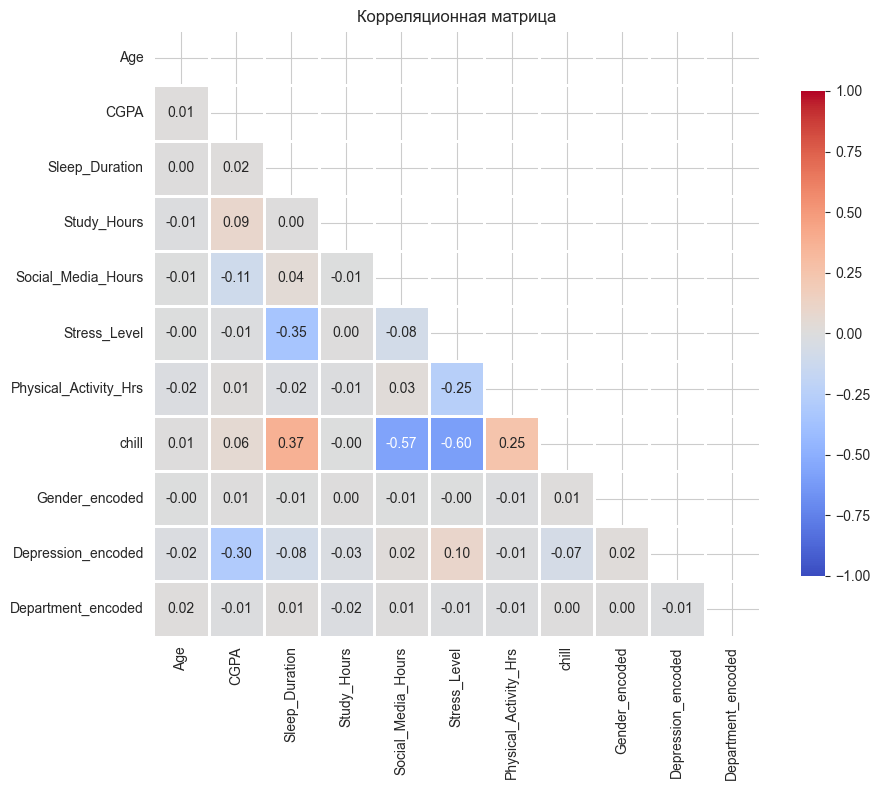

In [129]:
df_train_reg = df_train.copy()

print(f"До балансировки: {df_train.shape}, {len(df_train[df_train['Depression'] == True])/len(df_train):.2%}")
print(df_train.shape)

df_1 = df_train[df_train['Depression'] == True]
df_2 = df_train[df_train['Depression'] == False]

df_resample = resample(
    df_1,
    replace=True,
    n_samples=len(df_2),
    random_state=42,
)

df_train = pd.concat([df_2, df_resample])
df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"После балансировки: {len(df_train[df_train['Depression'] == True])/len(df_train):.2%}")
print(df_train.shape)

analyze_target(df_train)
run_corr(df_train)

Теперь баланс депрессии 1:1.
CGPA теперь более коррелирует с депрессией

Масштабирование и кодирование

Делаем fit_transorm только для обучающей выборки, чтобы не было утечек данных

In [130]:
for d in [df_train_reg, df_train, df_val, df_test]:
    d['Depression'] = d['Depression'].astype(int)


def prepare(df_train, df_val, df_test, target_col):
    y_train = df_train[target_col]
    y_val = df_val[target_col]
    y_test = df_test[target_col]

    X_train_raw = df_train.drop(target_col, axis=1)
    X_val_raw = df_val.drop(target_col, axis=1)
    X_test_raw = df_test.drop(target_col, axis=1)

    num_cols = X_train_raw.select_dtypes(include='number').columns.tolist()
    cat_cols = X_train_raw.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ])

    X_train = preprocessor.fit_transform(X_train_raw)
    X_val = preprocessor.transform(X_val_raw)
    X_test = preprocessor.transform(X_test_raw)

    features = preprocessor.get_feature_names_out()

    return X_train, X_val, X_test, y_train, y_val, y_test, features


X_train_reg, X_val_reg, X_test_reg, y_train_reg, y_val_reg, y_test_reg, features_reg = \
    prepare(df_train_reg, df_val, df_test, 'CGPA')

X_train_clf, X_val_clf, X_test_clf, y_train_clf, y_val_clf, y_test_clf, features_clf = \
    prepare(df_train, df_val, df_test, 'Depression')

## Обучение моделей

Вспомогательные функции для лин регрессии

In [131]:
def evaluate_regression(y_true, y_pred, dataset_name, need_print=True):
    """
    Вычисляет основные метрики для линейной регрессии

    y_true: Реальные значения целевой переменной
    y_pred: Предсказанные значения
    dataset_name: Название выборки
    need_print: Печатать ли метрики в консоль

    returns:
    dict: {'MAE', 'RMSE', 'R2', 'MAPE'}
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    if need_print:
        print(f"Метрики для {dataset_name}:")
        print(f"MAE: {mae:.2f}")
        print(f"RMSE: {rmse:.2f}")
        print(f"MAPE: {mape:.2f}")
        print(f"R^2: {r2:.2f}")

    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}


def plot_feature_importance(model, feature_names):
    """
    Строит barh-график весов признаков линейной модели.

    model: Обученная линейная модель (LinearRegression, LogisticRegression)
    feature_names: Список имён признаков
    """

    coefs = model.coef_
    if coefs.ndim == 2:
        coefs = coefs[0]
    
    plt.figure(figsize=(12, 6))
    colors = ['green' if w > 0 else 'red' for w in coefs]
    plt.barh(feature_names, coefs, color=colors)
    plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
    plt.title('Важность признаков')
    plt.xlabel('Вес коэфа')
    plt.tight_layout()
    plt.show()


def plot_learning_curve(model, X, y, scoring='r2'):
    """
    Кривая обучения: метрика vs размер обучающей выборки (train vs CV).

    model: Обучаемая модель sklearn
    X: Признаки
    y: Целевая переменная
    scoring: Метрика sklearn
    """
    train_sizes = np.linspace(0.1, 1.0, 10)
    
    train_sizes_abs, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=5,
        scoring=scoring,
        train_sizes=train_sizes,
        n_jobs=1,
        random_state=42
    )
    
    train_mean = np.mean(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    
    plt.figure(figsize=(12, 6))
    plt.plot(train_sizes_abs, train_mean, 'o-', color='#e74c3c', label='Train score')
    plt.plot(train_sizes_abs, val_mean, 'o-', color='#2ecc71', label='CV score')
    plt.title('Кривая обучения')
    plt.xlabel('Размер обучающей выборки')
    plt.ylabel(f'Метрика: {scoring}')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_residuals(y_true, y_pred, title='Распределение остатков'):
    """
    Гистограмма с KDE распределения остатков регрессии

    y_true: Истинные значения
    y_pred: Предсказанные значения
    title: Заголовок графика
    """
    residuals = y_true - y_pred
    
    plt.figure(figsize=(12, 6))
    sns.histplot(residuals, bins=50, kde=True, color='steelblue')
    plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
    plt.xlabel('Остаток')
    plt.ylabel('Частота')
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_actual_vs_predicted(y_true, y_pred, title='Факт vs Прогноз'):
    """График факт vs пронгоз

    y_true: Истинные значения
    y_pred: Предсказанные значения
    title: Заголовок графика
    """
    plt.figure(figsize=(10, 8))
    plt.scatter(y_true, y_pred, alpha=0.3, color='steelblue', edgecolors='navy', s=20)
    
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    
    plt.xlabel('Факт')
    plt.ylabel('Прогноз')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_metrics_comparison(train_metrics, val_metrics, test_metrics, metrics_names=None):
    """
    Группированная столбчатая диаграмма train/val/test

    Принимаются словари метрик для каждой из выборок
    """
    if metrics_names is None:
        metrics_names = ['R2', 'MAE', 'RMSE']
    
    x = np.arange(len(metrics_names))
    width = 0.25
    
    train_vals = [train_metrics[m] for m in metrics_names]
    val_vals = [val_metrics[m] for m in metrics_names]
    test_vals = [test_metrics[m] for m in metrics_names]
    
    plt.figure(figsize=(12, 6))
    plt.bar(x - width, train_vals, width, label='Train', color='#3498db')
    plt.bar(x, val_vals, width,label='Validation', color='#f39c12')
    plt.bar(x + width, test_vals, width, label='Test', color='#2ecc71')
     
    plt.xticks(x, metrics_names)
    plt.ylabel('Значение метрики')
    plt.title('Сравнение метрик: Train vs Val vs Test')
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

Обучение линейной регрессии и визуализация результатов

Метрики для Train:
MAE: 0.44
RMSE: 0.52
MAPE: 16.12
R^2: 0.05
Метрики для Validation:
MAE: 0.45
RMSE: 0.53
MAPE: 16.21
R^2: 0.02
Метрики для Test:
MAE: 0.45
RMSE: 0.52
MAPE: 16.13
R^2: 0.02


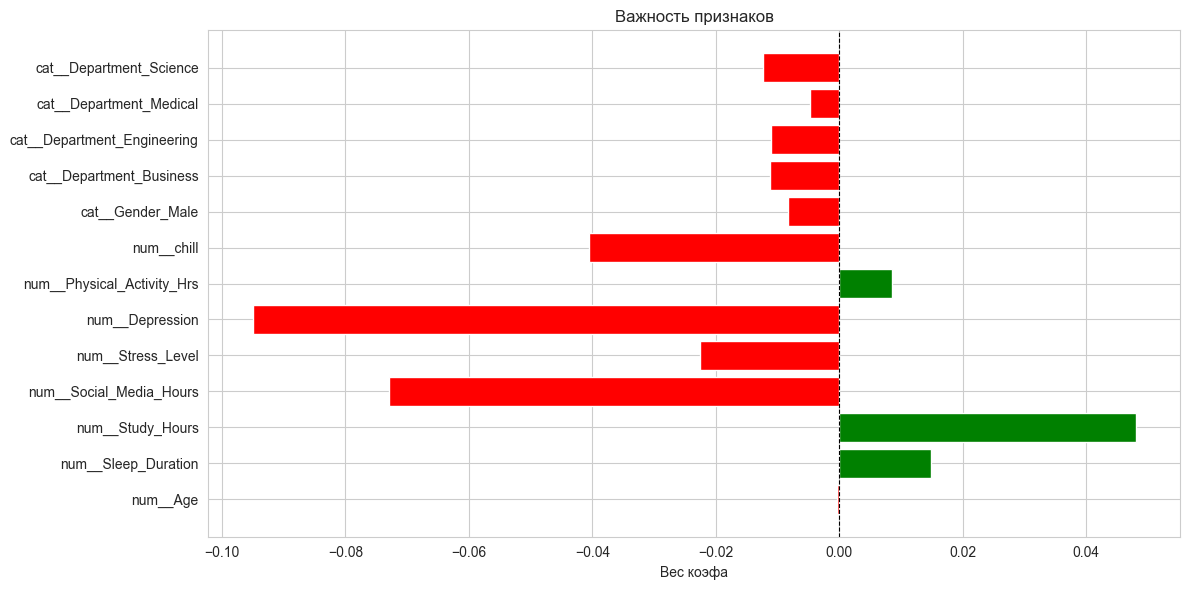

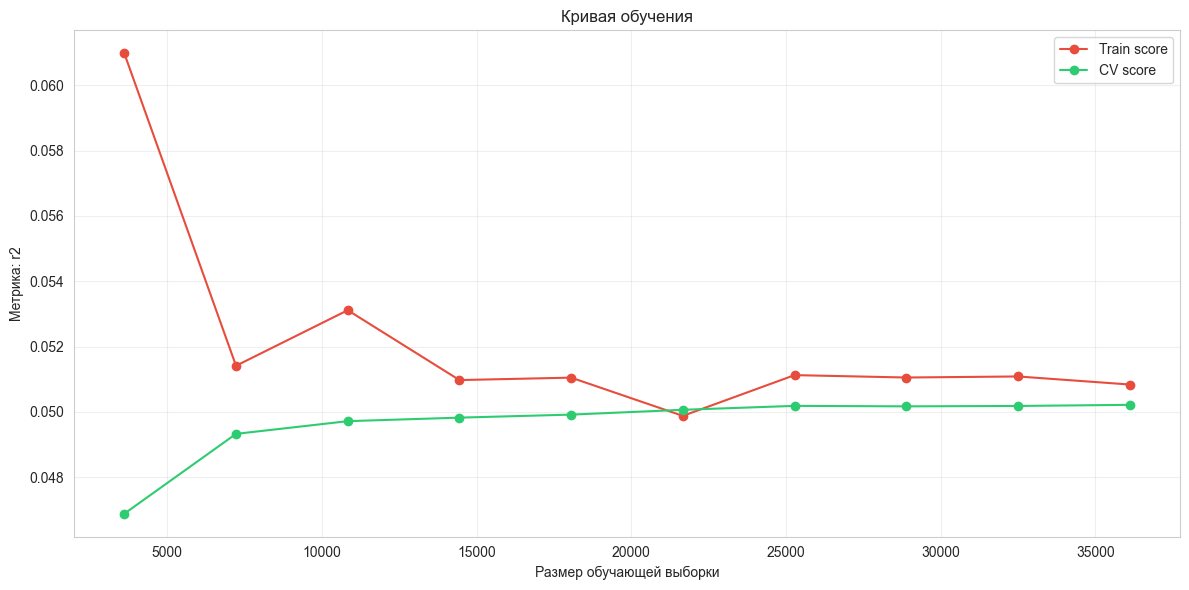

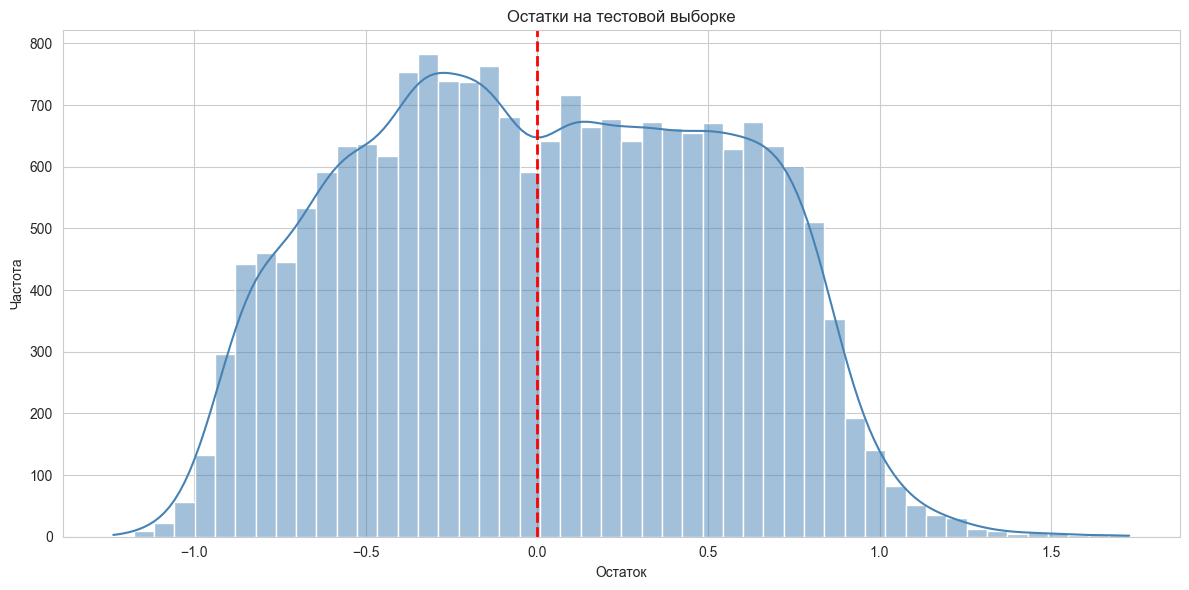

/var/folders/66/vlzff2117010kvrm0hkx_q9r0000gn/T/ipykernel_27893/1005363310.py:122: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


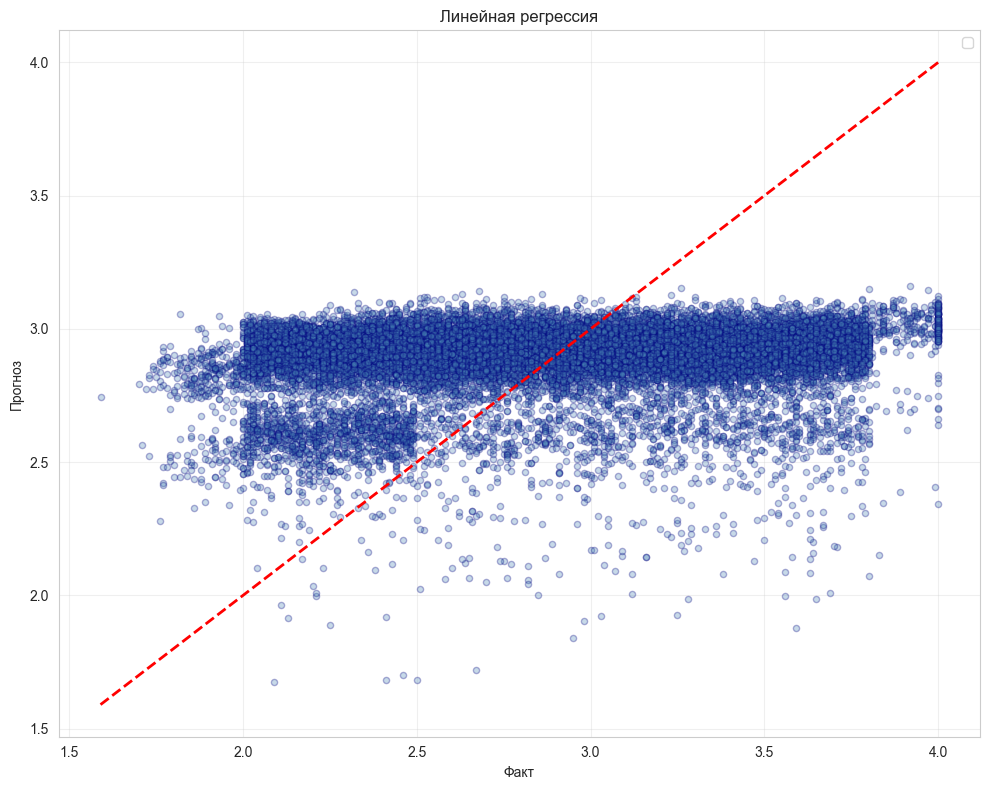

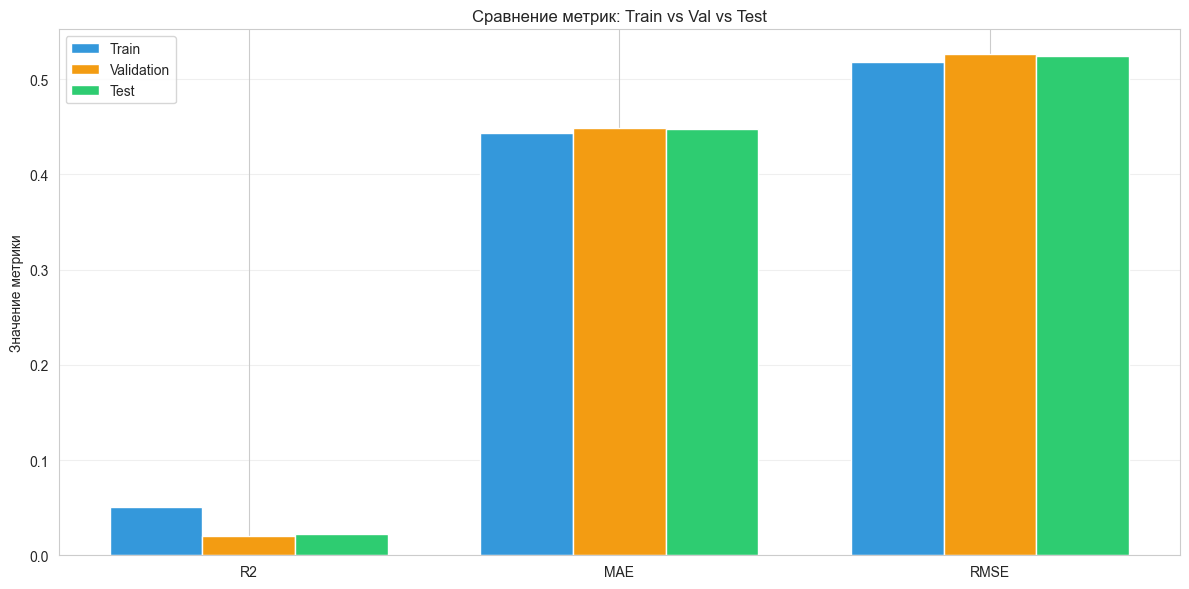

In [132]:
lr_model = LinearRegression()
lr_model.fit(X_train_reg, y_train_reg)

y_train_pred = lr_model.predict(X_train_reg)
y_val_pred = lr_model.predict(X_val_reg)
y_test_pred = lr_model.predict(X_test_reg)

train_metrics = evaluate_regression(y_train_reg, y_train_pred, "Train")
val_metrics = evaluate_regression(y_val_reg, y_val_pred, "Validation")
test_metrics = evaluate_regression(y_test_reg, y_test_pred, "Test")

plot_feature_importance(lr_model, features_reg)
plot_learning_curve(lr_model, X_train_reg, y_train_reg, scoring='r2')

plot_residuals(y_test_reg, y_test_pred, title='Остатки на тестовой выборке')
plot_actual_vs_predicted(y_test_reg, y_test_pred, title='Линейная регрессия')
plot_metrics_comparison(train_metrics, val_metrics, test_metrics)

R^2 показывает что модель тупая, усредняет значения
Важными признаками, влияющими на успеваемость - Учеба, Депрессия, чилл, время в соц сетях
Остатки не сосредоточены около вертикальной линии
На последнем графике столбчатые диаграммы почти совпадают что на тестовой, валидационной и обучающей выборках -> не переобучена

Вспомогательные функции для логистической регрессии

In [133]:
def evaluate_classification(y_true, y_pred, y_proba, dataset_name, need_print=True):
    """Вычисляет метрики классификации Accuracy, Precision, Recall, F1, ROC-AUC, Log-Loss и опционально выводит их"""

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)
    loss = log_loss(y_true, y_proba)

    if need_print:
        print(f"{dataset_name} метрики:")
        print(f"Accuracy: {acc:.2f}")
        print(f"Precision: {prec:.2f}")
        print(f"Recall: {rec:.2f}")
        print(f"F1-score: {f1:.2f}")
        print(f"ROC-AUC: {auc:.2f}")
        print(f"Log-Loss: {loss:.2f}\n")

    return {
        'Accuracy': acc, 'Precision': prec, 'Recall': rec,
        'F1': f1, 'ROC-AUC': auc, 'Log-Loss': loss
    }


def plot_confusion_matrix_heatmap(y_true, y_pred, title='Confusion Matrix'):
    """Строит confusion matrix для бинарной классификации"""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Depression', 'Depression'],
                yticklabels=['No Depression', 'Depression'])
    plt.title(title)
    plt.ylabel('Факт')
    plt.xlabel('Прогноз')
    plt.tight_layout()
    plt.show()


def plot_roc_curve_model(y_true, y_proba, title='ROC Curve'):
    """Строит ROC-кривую с расчётом AUC"""
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    auc = roc_auc_score(y_true, y_proba)

    plt.figure(figsize=(10, 8))
    plt.plot(fpr, tpr, color='darkorange', lw=2,label=f'ROC-кривая (AUC = {auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Случайный классификатор')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_loss_over_epochs(train_losses, val_losses, title='Loss Curve'):
    """Строит график изменения Log-Loss на train и validation по эпохам"""
    plt.figure(figsize=(12, 6))
    plt.plot(train_losses, label='Train Loss', color='#e74c3c', linewidth=2)
    plt.plot(val_losses, label='Val Loss', color='#2ecc71', linewidth=2)
    plt.xlabel('Эпоха')
    plt.ylabel('Log Loss')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_metrics_comparison_clf(train_metrics, val_metrics, test_metrics, metrics_names=None):
    """Группированная столбчатая диаграмма для сравнения метрик классификации Train / Val / Test"""

    if metrics_names is None:
        metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']

    x = np.arange(len(metrics_names))
    width = 0.25

    train_vals = [train_metrics[m] for m in metrics_names]
    val_vals = [val_metrics[m] for m in metrics_names]
    test_vals = [test_metrics[m] for m in metrics_names]

    plt.figure(figsize=(12, 6))
    plt.bar(x - width, train_vals, width, label='Train', color='#3498db')
    plt.bar(x, val_vals, width, label='Validation', color='#f39c12')
    plt.bar(x + width, test_vals, width, label='Test', color='#2ecc71')

    plt.xticks(x, metrics_names)
    plt.ylabel('Значение метрики')
    plt.title('Сравнение метрик: Train vs Val vs Test')
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

Эксперимент с подбором шага и количества эпох обучения

In [134]:
learning_rates = [0.0001, 0.001, 0.01, 0.1]
max_epochs = 150

all_results = {}

for lr in learning_rates:
    sgd = SGDClassifier(
        loss='log_loss',
        learning_rate='constant',
        eta0=lr,
        random_state=42
    )

    train_losses = []
    val_losses = []

    for epoch in range(max_epochs):
        sgd.partial_fit(X_train_clf, y_train_clf, classes=[0, 1])

        train_proba = sgd.predict_proba(X_train_clf)[:, 1]
        val_proba = sgd.predict_proba(X_val_clf)[:, 1]

        train_losses.append(log_loss(y_train_clf, train_proba))
        val_losses.append(log_loss(y_val_clf, val_proba))

    all_results[lr] = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'model': sgd
    }


best_lr = None
best_epoch = None
best_val_loss = float('inf')

for lr in learning_rates:
    res = all_results[lr]
    ep = np.argmin(res['val_losses']) + 1
    vl = res['val_losses'][ep - 1]
    tl = res['train_losses'][ep - 1]
    gap = vl - tl
    print(f"Эпоха: {ep}")
    print(f"Шаг обучения: {lr}")
    print(f"train loss: {tl:.2f}")
    print(f"val loss: {vl:.2f}")
    print(f"gap: {gap:.2f}")
    print()

    if vl < best_val_loss:
        best_val_loss = vl
        best_lr = lr
        best_epoch = ep

print(f"Лучшая комбинация learning_rate: {best_lr}, epoch: {best_epoch}")

Эпоха: 1
Шаг обучения: 0.0001
train loss: 0.64
val loss: 0.63
gap: -0.01

Эпоха: 1
Шаг обучения: 0.001
train loss: 0.64
val loss: 0.65
gap: 0.01

Эпоха: 1
Шаг обучения: 0.01
train loss: 0.65
val loss: 0.60
gap: -0.04

Эпоха: 1
Шаг обучения: 0.1
train loss: 0.67
val loss: 0.66
gap: -0.01

Лучшая комбинация learning_rate: 0.01, epoch: 1


Эксперимент с подбором шага показал, что модель SGDClassifier сходится за одну эпоху при любом шаге обучения, но лучшим из кандидатов стал шаг=0.01 с наименьшим val loss (0.60)

Обучение логистической регрессии

Train метрики:
Accuracy: 0.66
Precision: 0.65
Recall: 0.69
F1-score: 0.67
ROC-AUC: 0.69
Log-Loss: 0.64

Validation метрики:
Accuracy: 0.60
Precision: 0.16
Recall: 0.70
F1-score: 0.26
ROC-AUC: 0.67
Log-Loss: 0.67

Test метрики:
Accuracy: 0.61
Precision: 0.16
Recall: 0.69
F1-score: 0.26
ROC-AUC: 0.68
Log-Loss: 0.67



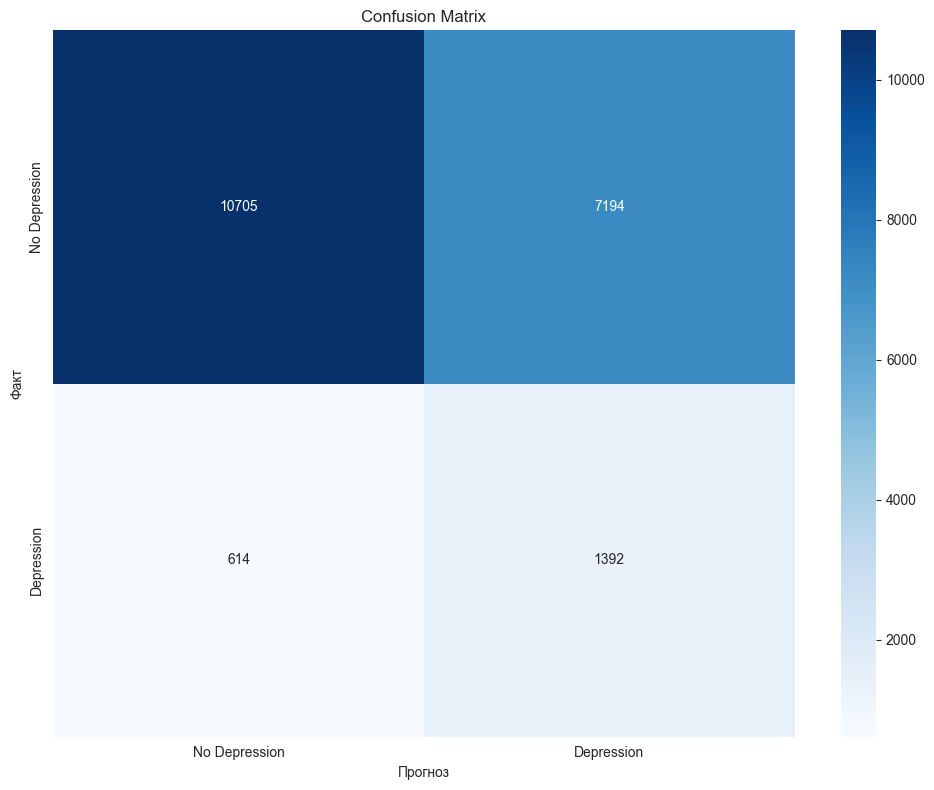

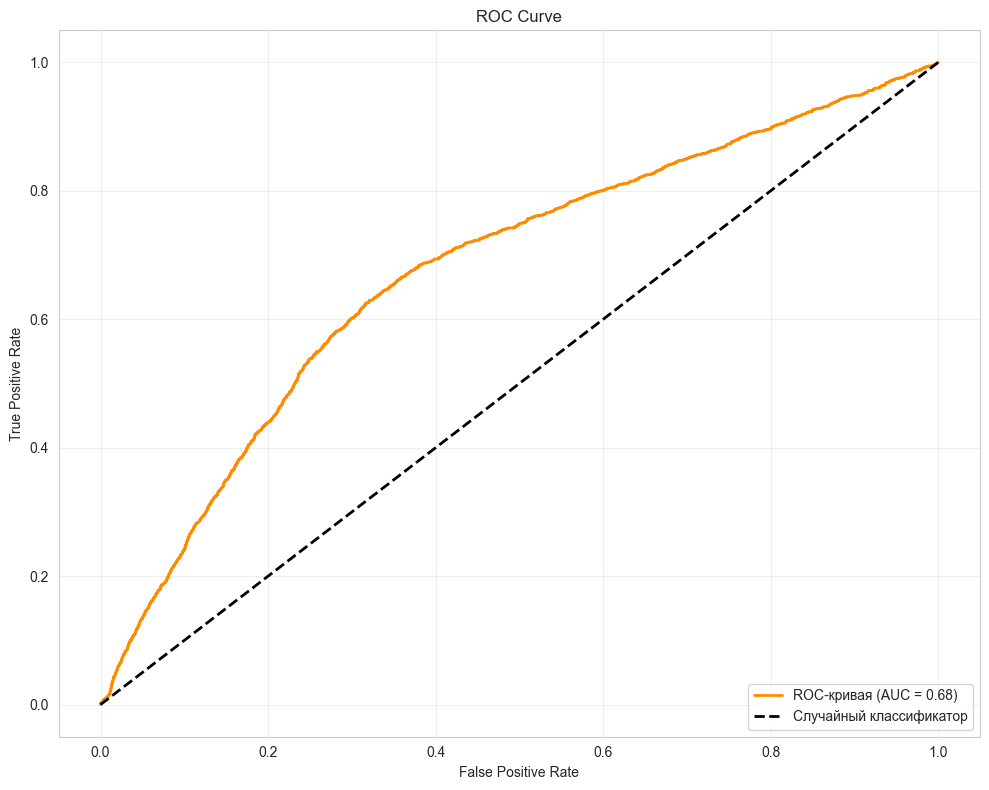

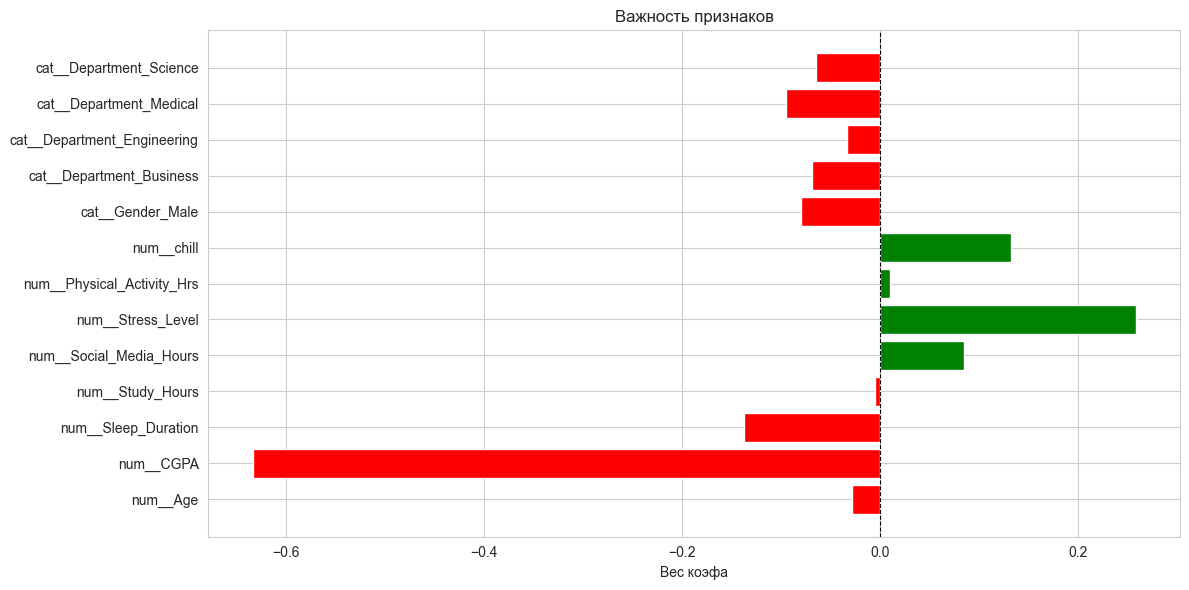

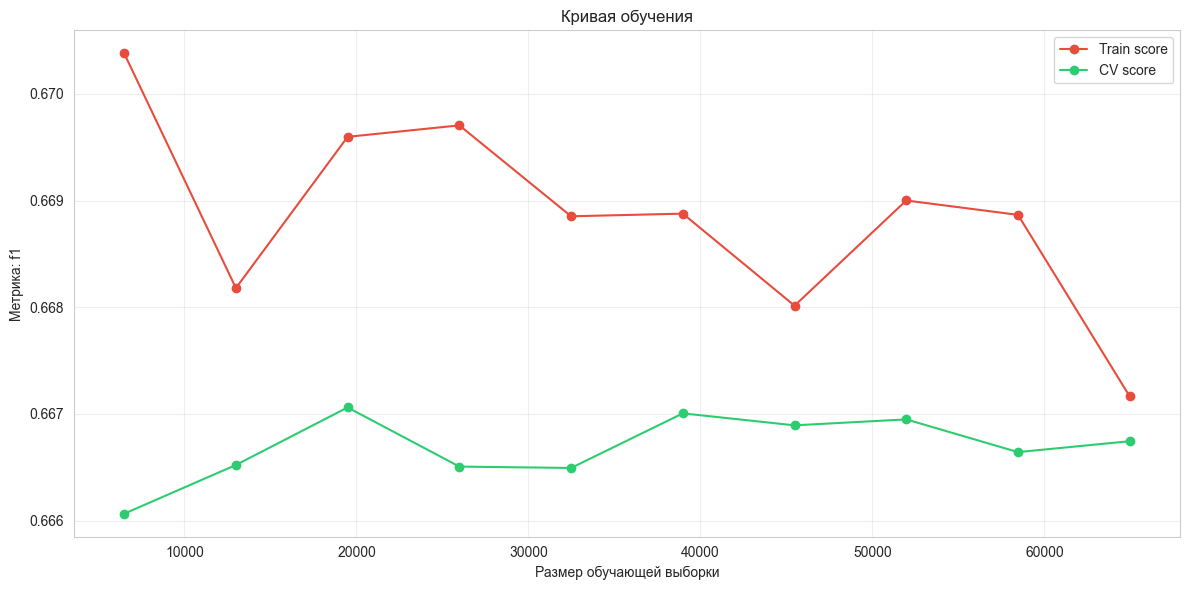

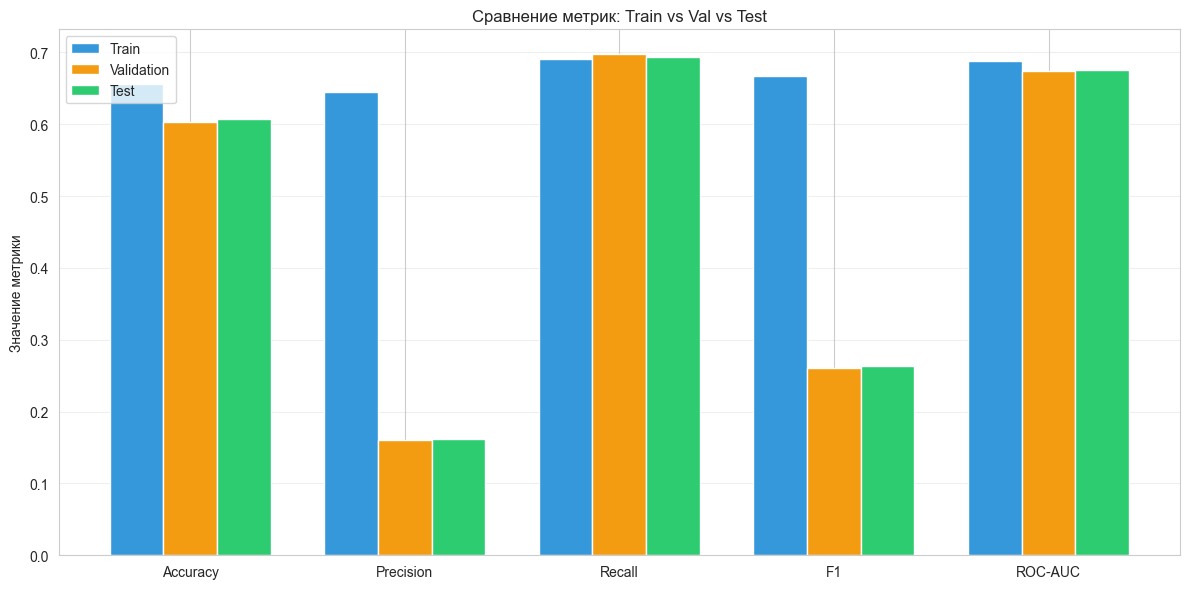

In [135]:
log_model = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs', random_state=42)

log_model.fit(X_train_clf, y_train_clf)

y_train_pred = log_model.predict(X_train_clf)
y_val_pred = log_model.predict(X_val_clf)
y_test_pred = log_model.predict(X_test_clf)

y_train_proba = log_model.predict_proba(X_train_clf)[:, 1]
y_val_proba = log_model.predict_proba(X_val_clf)[:, 1]
y_test_proba = log_model.predict_proba(X_test_clf)[:, 1]

train_metrics_clf = evaluate_classification(y_train_clf, y_train_pred, y_train_proba, "Train")
val_metrics_clf = evaluate_classification(y_val_clf, y_val_pred, y_val_proba, "Validation")
test_metrics_clf = evaluate_classification(y_test_clf, y_test_pred, y_test_proba, "Test")


plot_confusion_matrix_heatmap(y_test_clf, y_test_pred,title='Confusion Matrix')

plot_roc_curve_model(y_test_clf, y_test_proba, title='ROC Curve')

plot_feature_importance(log_model, features_clf)

plot_learning_curve(log_model, X_train_clf, y_train_clf, scoring='f1')

plot_metrics_comparison_clf(train_metrics_clf, val_metrics_clf, test_metrics_clf)


Кривая обучения логистической регрессии показывает стабильный F1-score на кросс валидации при любом размере обучающей выборки, а небольшой разрыв между train и cv свидетельствует, что переобучения не произошло

Посмотрим на крайний график. Особенно интересует разница в precision, f1, Почему это не переобучение? Потому что модель обучалась на сбалансированных данных с соотношением 1:1 у депрессии, а валидация и тестирующая выборки по прежнему 1:9. Показатели рекола важнее в нашем случае важнее, ведь лучше вызвать ложную тревогу, чем пропустить больного с депресссий.

## Обучение моделей на мелких датасетах

Обучение линейной регрессии после изменения нашего датасета

Метрики для Train:
MAE: 0.44
RMSE: 0.52
MAPE: 16.13
R^2: 0.05
Метрики для Validation:
MAE: 0.44
RMSE: 0.52
MAPE: 16.16
R^2: 0.05
Метрики для Test:
MAE: 0.44
RMSE: 0.52
MAPE: 16.10
R^2: 0.05


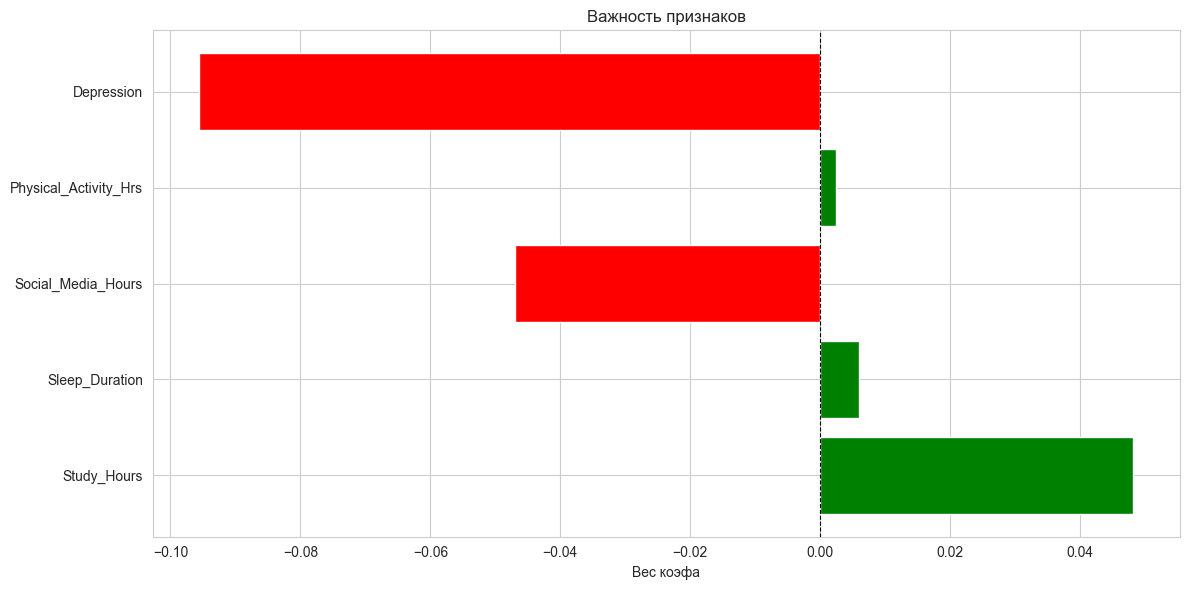

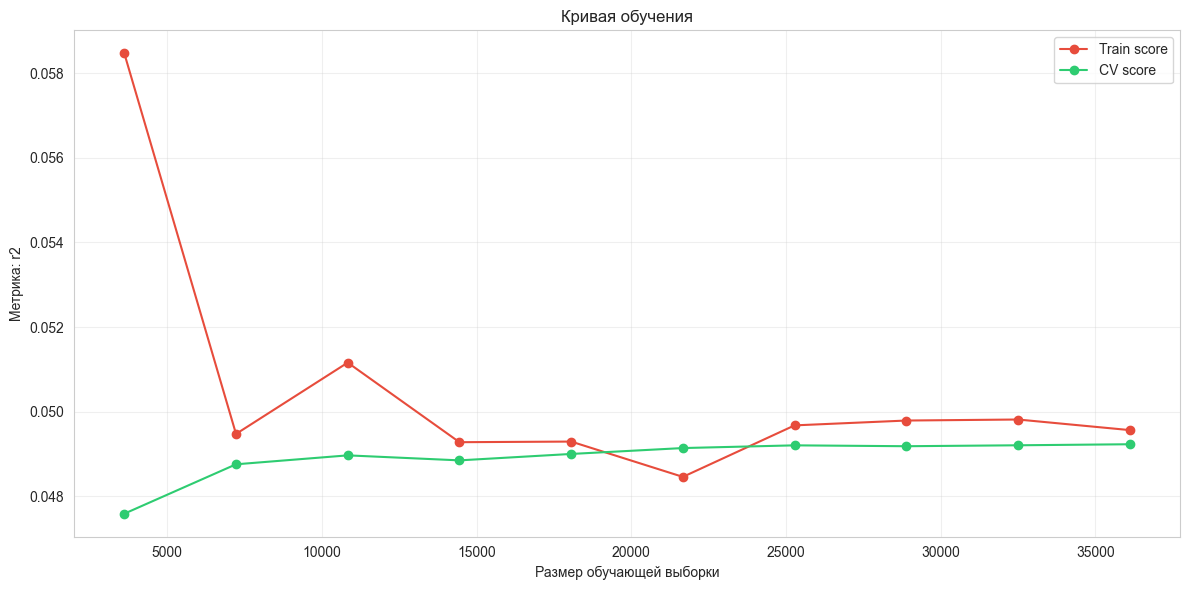

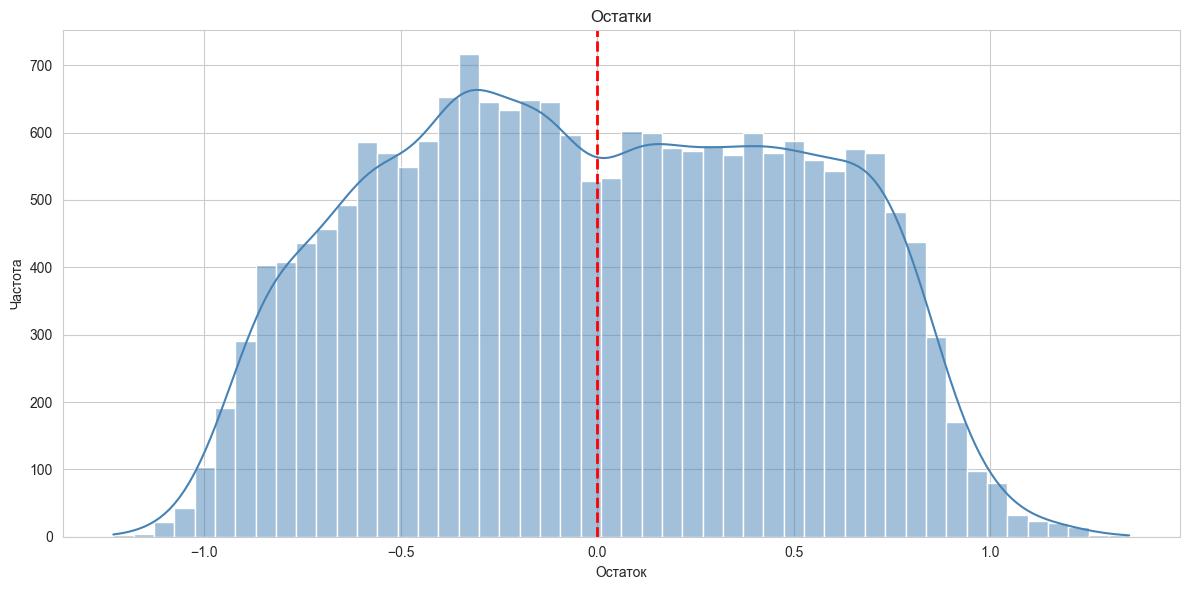

/var/folders/66/vlzff2117010kvrm0hkx_q9r0000gn/T/ipykernel_27893/1005363310.py:122: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


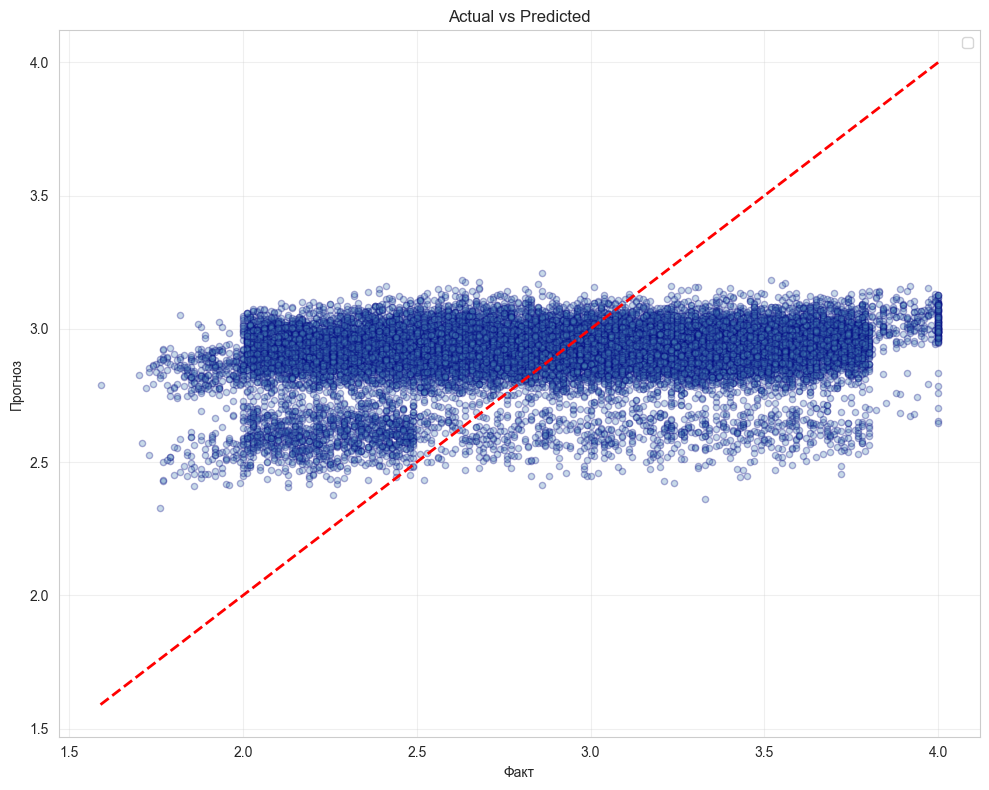

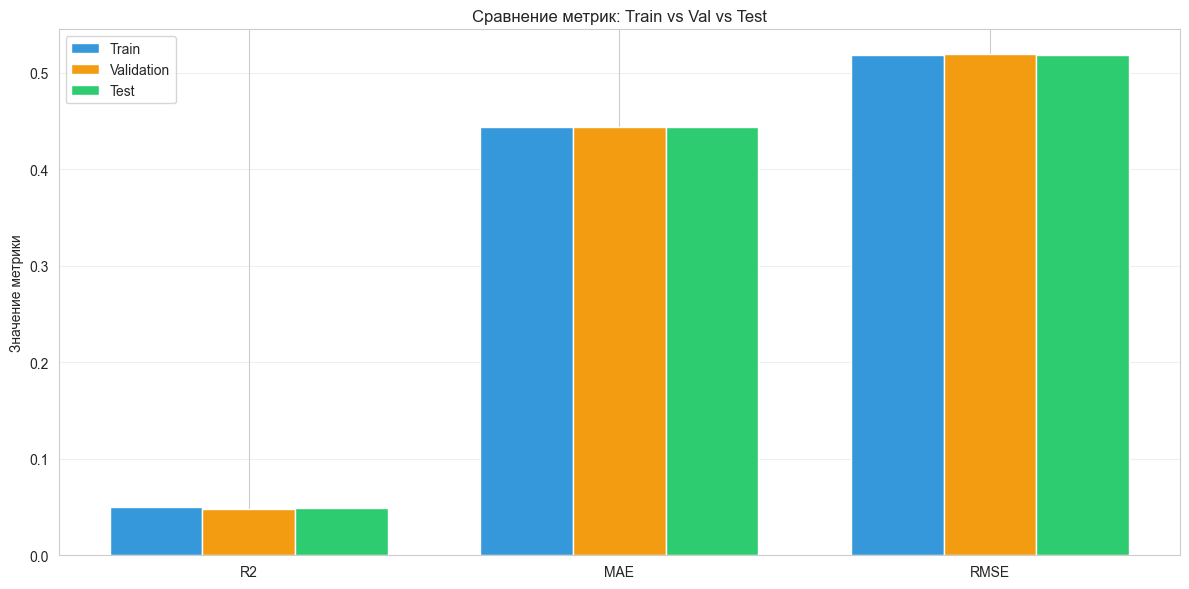

In [136]:
features_reg_small = ['Study_Hours', 'Sleep_Duration', 'Social_Media_Hours', 'Physical_Activity_Hrs', 'Depression']

X_train_reg_s = df_train_reg[features_reg_small]
y_train_reg_s = df_train_reg['CGPA']
X_val_reg_s = df_val[features_reg_small]
y_val_reg_s = df_val['CGPA']
X_test_reg_s = df_test[features_reg_small]
y_test_reg_s = df_test['CGPA']

scaler_reg_s = StandardScaler()
X_train_reg_s = scaler_reg_s.fit_transform(X_train_reg_s)
X_val_reg_s = scaler_reg_s.transform(X_val_reg_s)
X_test_reg_s = scaler_reg_s.transform(X_test_reg_s)

lr_model_s = LinearRegression()
lr_model_s.fit(X_train_reg_s, y_train_reg_s)

y_train_pred_s = lr_model_s.predict(X_train_reg_s)
y_val_pred_s = lr_model_s.predict(X_val_reg_s)
y_test_pred_s = lr_model_s.predict(X_test_reg_s)

train_m_s = evaluate_regression(y_train_reg_s, y_train_pred_s, "Train")
val_m_s = evaluate_regression(y_val_reg_s, y_val_pred_s, "Validation")
test_m_s = evaluate_regression(y_test_reg_s, y_test_pred_s, "Test")

plot_feature_importance(lr_model_s, features_reg_small)
plot_learning_curve(lr_model_s, X_train_reg_s, y_train_reg_s, scoring='r2')
plot_residuals(y_test_reg_s, y_test_pred_s, title='Остатки')
plot_actual_vs_predicted(y_test_reg_s, y_test_pred_s, title='Actual vs Predicted')
plot_metrics_comparison(train_m_s, val_m_s, test_m_s)


Обучение логистической регрессии после изменения датасета

Train метрики:
Accuracy: 0.65
Precision: 0.64
Recall: 0.68
F1-score: 0.66
ROC-AUC: 0.68
Log-Loss: 0.64

Validation метрики:
Accuracy: 0.62
Precision: 0.16
Recall: 0.68
F1-score: 0.26
ROC-AUC: 0.68
Log-Loss: 0.64

Test метрики:
Accuracy: 0.62
Precision: 0.16
Recall: 0.66
F1-score: 0.26
ROC-AUC: 0.68
Log-Loss: 0.64



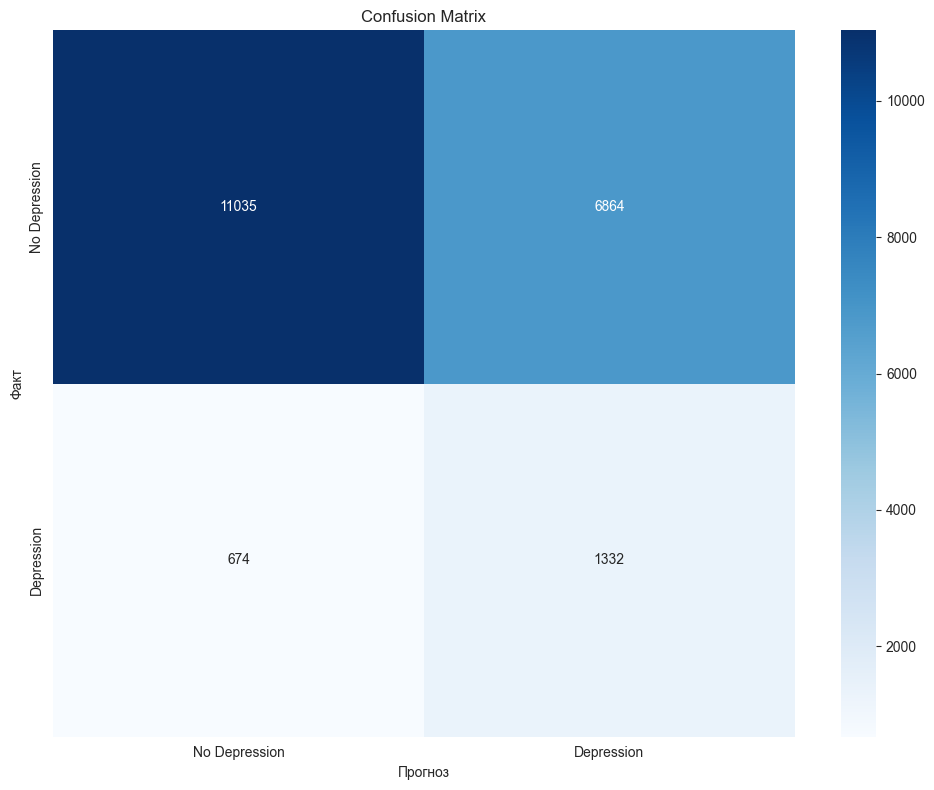

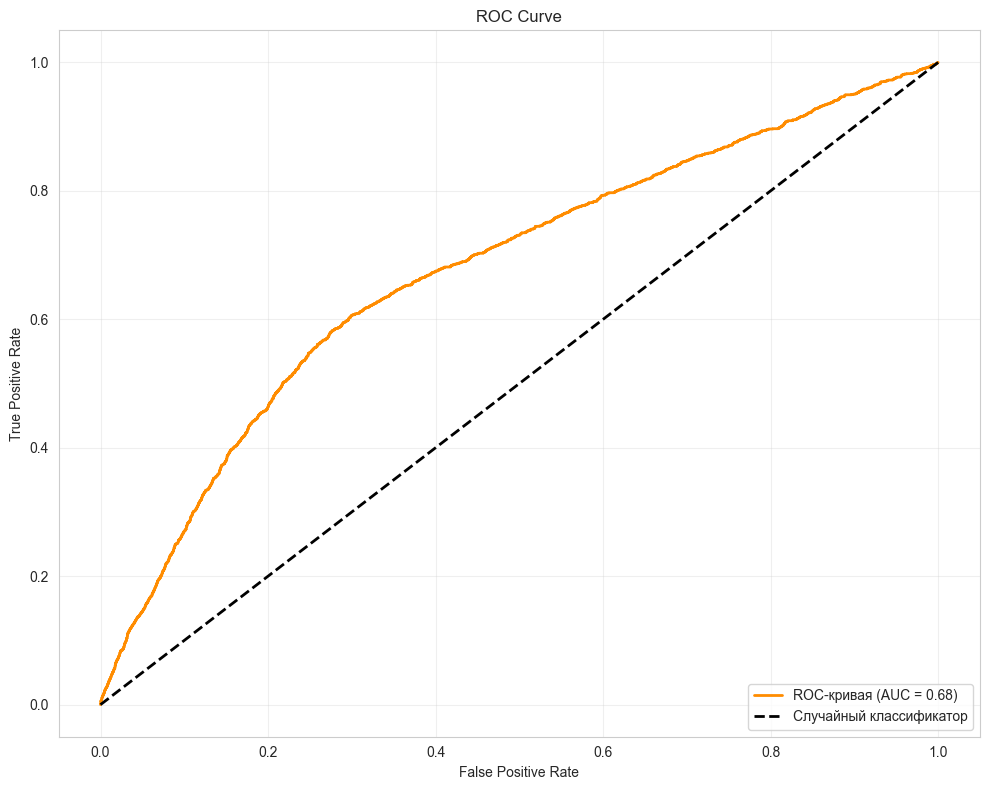

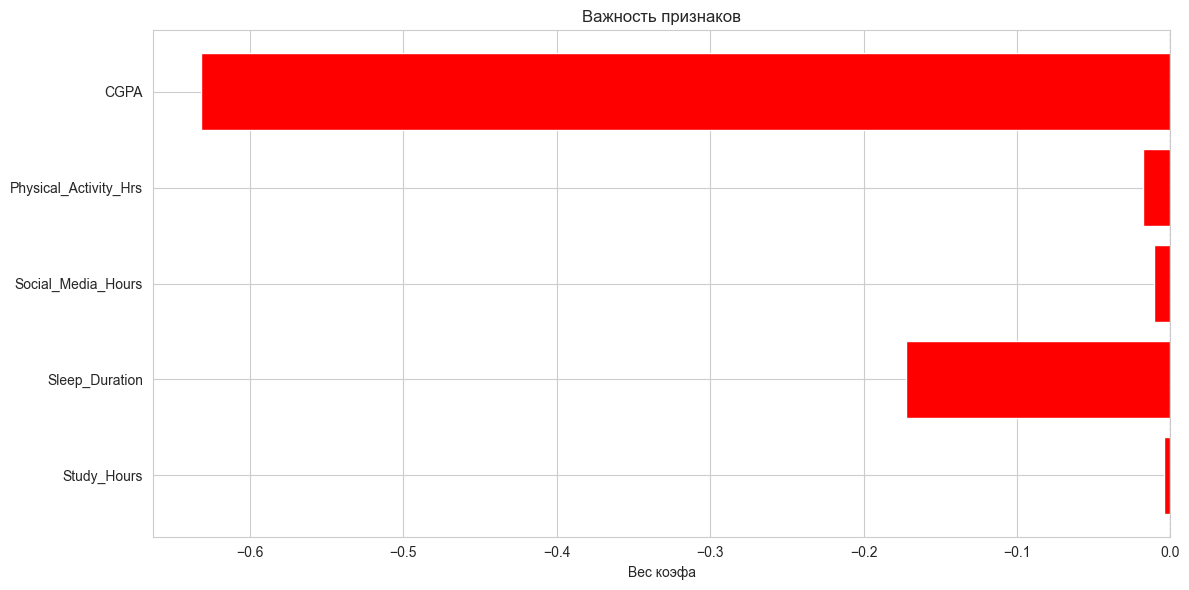

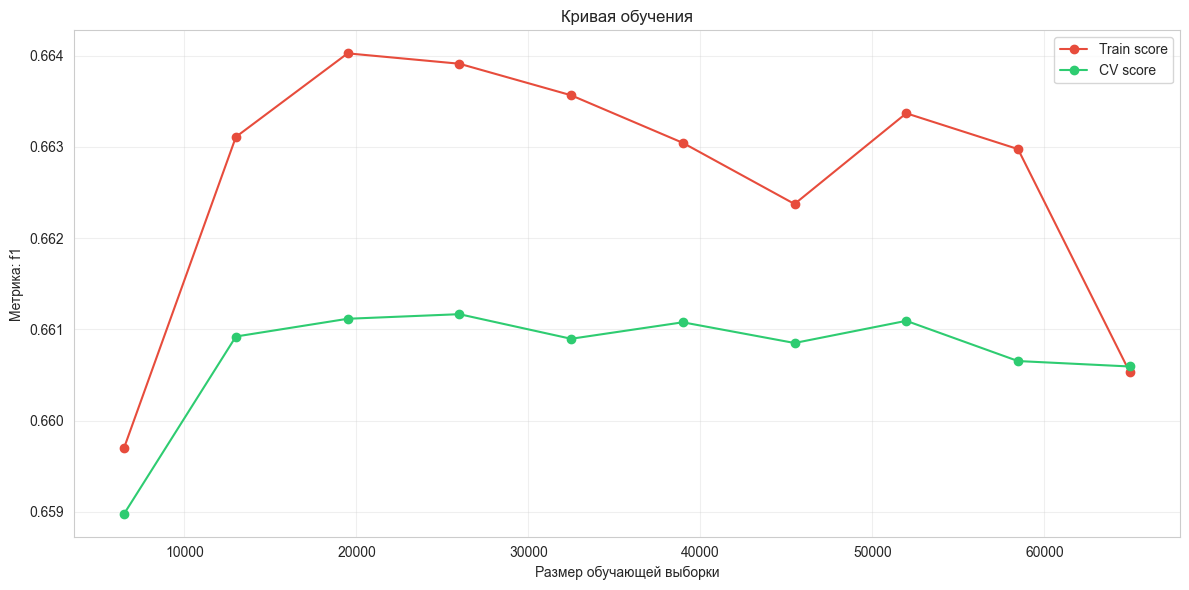

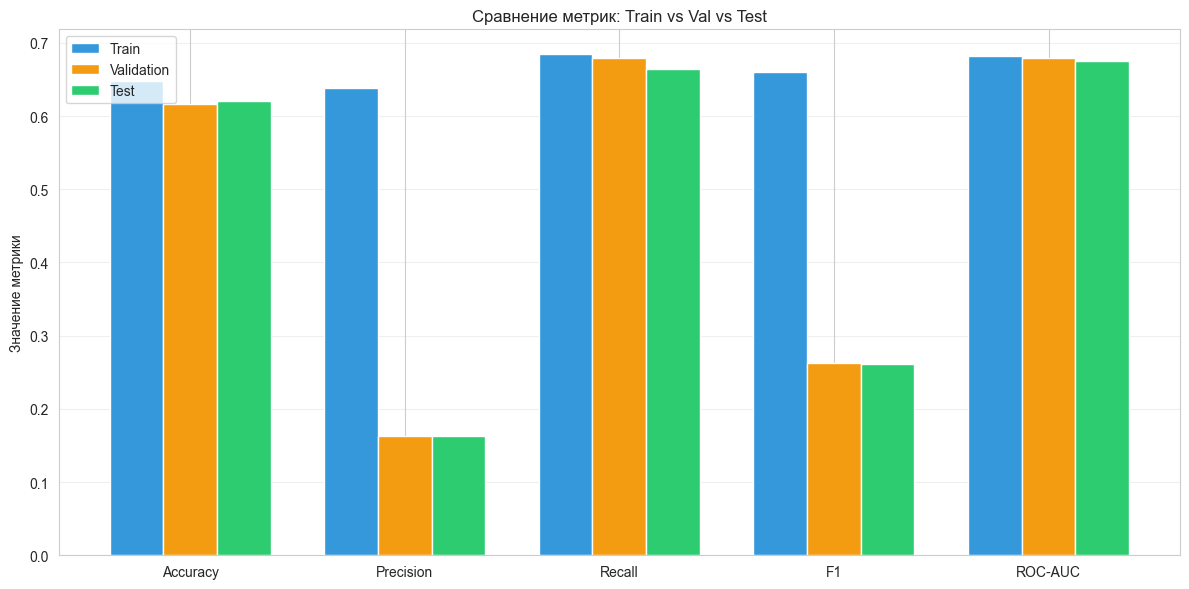

In [137]:
features_clf_small = ['Study_Hours', 'Sleep_Duration', 'Social_Media_Hours', 'Physical_Activity_Hrs', 'CGPA']

X_train_clf_s = df_train[features_clf_small]
y_train_clf_s = df_train['Depression']
X_val_clf_s = df_val[features_clf_small]
y_val_clf_s = df_val['Depression']
X_test_clf_s = df_test[features_clf_small]
y_test_clf_s = df_test['Depression']

scaler_clf_s = StandardScaler()
X_train_clf_s = scaler_clf_s.fit_transform(X_train_clf_s)
X_val_clf_s = scaler_clf_s.transform(X_val_clf_s)
X_test_clf_s = scaler_clf_s.transform(X_test_clf_s)

log_model_s = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs', random_state=42)
log_model_s.fit(X_train_clf_s, y_train_clf_s)

y_train_pred_s = log_model_s.predict(X_train_clf_s)
y_val_pred_s = log_model_s.predict(X_val_clf_s)
y_test_pred_s = log_model_s.predict(X_test_clf_s)

y_train_proba_s = log_model_s.predict_proba(X_train_clf_s)[:, 1]
y_val_proba_s = log_model_s.predict_proba(X_val_clf_s)[:, 1]
y_test_proba_s = log_model_s.predict_proba(X_test_clf_s)[:, 1]

train_m_clf_s = evaluate_classification(y_train_clf_s, y_train_pred_s, y_train_proba_s, "Train")
val_m_clf_s = evaluate_classification(y_val_clf_s, y_val_pred_s, y_val_proba_s, "Validation")
test_m_clf_s = evaluate_classification(y_test_clf_s, y_test_pred_s, y_test_proba_s, "Test")

plot_confusion_matrix_heatmap(y_test_clf_s, y_test_pred_s, title='Confusion Matrix')
plot_roc_curve_model(y_test_clf_s, y_test_proba_s, title='ROC Curve')
plot_feature_importance(log_model_s, features_clf_small)
plot_learning_curve(log_model_s, X_train_clf_s, y_train_clf_s, scoring='f1')
plot_metrics_comparison_clf(train_m_clf_s, val_m_clf_s, test_m_clf_s)

## Выводы

Обе модели не показали признаков переобучения. Датасеты в конце были видоизменены (удалены некоторые колонки), результат оказался схож с полным датасетом. Это значит, что эти данные не сильно влияли на результат и их можно спокойной удалить, дабы размер датасета и время на обучения сократились.
Была проведена предобработка данных с удалением аномалий, выбросов. Для логистической регрессии пришлось делать балансировку, иначе она бы начала предсказывать только самый дисбалансный класс, в нашем случае no depression, и на тестовой выборке показывала бы высокий precision, но низкий recall, хотя важен именно он.
Сам датасет слишком чистый, а наиболее важным признаком при предсказывании депрессии оказался CGPA и наоборот, при предсказании депрессии CGPA оказался самым важным.



## Здесь можно вбивать свои данные и смотреть на ответ обученный моделей

In [138]:
my_data = pd.DataFrame([{
    'Study_Hours': 10,
    'Sleep_Duration': 7,
    'Social_Media_Hours': 1.5,
    'Physical_Activity_Hrs': 1,
    'Depression': 0
}])

my_scaled = scaler_reg_s.transform(my_data)
predicted_cgpa = lr_model_s.predict(my_scaled)
print(f"Предсказанный CGPA: {predicted_cgpa[0]:.2f}")


my_data = pd.DataFrame([{
    'Study_Hours': 10,
    'Sleep_Duration': 7,
    'Social_Media_Hours': 1.5,
    'Physical_Activity_Hrs': 1,
    'CGPA': 3.2
}])

my_scaled = scaler_clf_s.transform(my_data)
pred = log_model_s.predict(my_scaled)[0]
proba = log_model_s.predict_proba(my_scaled)[0, 1]
print(f"Депрессия: {'Да' if pred else 'Нет'} (вероятность: {proba:.2%})")


Предсказанный CGPA: 3.14
Депрессия: Нет (вероятность: 37.41%)
